# Collection Équinoxe — Prévision de la hausse de loyer 2026

## Résumé exécutif

### Estimation centrale

\[
\boxed{4,51\%}
\]

Nous définissons la hausse de loyer comme la **croissance médiane annualisée
du loyer effectif (`sRentEffective`) à unité constante**.

Notre estimation centrale pour 2026 est de **4,51 %**, accompagnée d'une
plage de sensibilité empirique d'environ **3,04 % à 5,99 %**.

### Performance historique

La méthode obtient une MAE d'environ **1,48 point de pourcentage** sur les
backtests officiels 2023, 2024 et 2025.

Elle est légèrement meilleure que la baseline consistant à reprendre la
croissance de l'année précédente.

### Trois résultats clés

1. **L'effet de composition est majeur.** En 2023, la médiane brute du
   portefeuille augmente de 10,85 %, alors que la croissance contractuelle
   à unité constante n'est que de 2,29 %.

2. **Les concessions modifient fortement le signal économique.** En 2025,
   la croissance contractuelle médiane atteint environ 7,05 %, contre
   seulement 3,58 % en loyer effectif.

3. **Le contexte réglementaire et le marché doivent être segmentés.**
   Les renouvellements et relocations sont distingués, et The Met est traité
   séparément en raison des règles ontariennes.

### Méthode retenue

\[
Forecast_t
=
AskingGrowth_{t-1}
-
ConcessionDrag_{t-1}
\]

Le notebook documente ensuite chaque étape ayant conduit à ce résultat :
audit des données, effet de mix, appariement à unité constante, concessions,
renouvellements vs relocations, données externes, backtests, sensibilité et
prévisions segmentées.

## 1. Charger les données

## 1b. Lire les colonnes : champs `h` et champs `s`

Chaque colonne de ce jeu commence par **`h`** ou **`s`**. C'est la convention de Yardi, et
se tromper là-dessus est la façon la plus courante de corrompre une requête de gestion immobilière.

| préfixe | signification | exemple | à quoi ça sert |
|---|---|---|---|
| **`h`** | **handle** (identifiant) - une clé numérique | `hUnit`, `hProperty`, `hBuilding` | **les jointures**. Opaque, stable, unique. |
| **`s`** | **stored value** (valeur stockée) - ce qu'un humain lit | `sUnitCode`, `sRent`, `sBuilding` | **l'affichage et le regroupement**. |

Yardi conserve les deux moitiés d'une même information côte à côte - `hAgent` à côté de `sAgent`,
`hProperty` à côté de `sPropCode`. Elles ne sont **pas interchangeables** :

> **Joindre sur `h`. Étiqueter avec `s`.**

Ce n'est pas du pinaillage, c'est tout l'objet de la section 4 ci-dessous. `sUnitCode` vaut `"0203"` - et
trois appartements différents sur un même site portent cette même chaîne. `hUnit` est unique par
construction. Si vous associez une unité à elle-même du côté `s`, vous fusionnez des appartements sans le savoir;
si vous associez sur `hUnit`, c'est impossible.

**Deux mises en garde sur `s`, qui reflètent toutes deux le vrai comportement de Yardi, pas des particularités de ce jeu :**

1. **`s` ne veut pas dire « string ».** La table `UNIT` de Yardi stocke `SRENT` et `DSQFT` comme
   *valeurs numériques*. Ici, `sRent` et `sSqft` sont des nombres. Ne déduisez pas un type d'un préfixe -
   vérifiez-le.
2. **Le vrai Yardi subdivise davantage le côté `s`** - `dt*` pour les dates (`dtLeaseFrom`), `d*`
   pour les doubles (`dSqft`), `i*` pour les entiers, `b*` pour les indicateurs. Ce jeu les ramène tous
   à `s` pour garder l'attention sur la distinction `h` / `s`. Quand vous ouvrirez la vraie base de données, attendez-vous
   à un alphabet plus long.

### Les codes de frais

`sChargeCode` dans le fichier des concessions correspond au plan comptable de Yardi. Les codes semblent abîmés
parce que `sCode` est un `nchar(8)` - « Free other » devient `Freeothe`, « Referencing » devient
`Referenc`. Huit caractères, tronqués, avec une casse incohérente. C'est à ça que ressemblent les vrais.

| `sChargeCode` | `sChargeDesc` | ce que c'est réellement |
|---|---|---|
| `PromoPay` | Promo - Payable in the future | Un rabais promotionnel. **Lisez la mise en garde ci-dessous.** |
| `freerent` | Free rent | Loyer annulé pour une partie du bail. |
| `freepark` | Free Parking | Frais de stationnement annulés. Un avantage *accessoire*, pas du loyer. |
| `freelock` | Free Locker | Casier de rangement offert. Accessoire. |
| `freeappl` | Free Appliances | Frais d'électroménagers annulés. Accessoire. |
| `Freeothe` | Free other | Tout ce qui n'est pas catégorisé. À traiter avec méfiance. |
| `Indem` | Client indemnity | Un paiement versé au résident, par exemple pour régler un différend. |
| `Referenc` | Referencing program | Un crédit de référencement. |

**Celui qu'il faut examiner avant de s'y fier :** `PromoPay` est décrit comme un frais
mensuel. Ce n'en est pas un. Il est très majoritairement inscrit sur un seul mois, pour un montant proche d'un mois
de loyer complet. Prenez la description au pied de la lettre et vous conclurez que les résidents habitent
presque gratuitement. Comparez `sMonths` et la taille de `sAmount` à `sRent` avant de le modéliser -
et décidez vous-même comment l'étaler sur la durée du bail.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)

listings   = pd.read_csv("equinoxe_listings.csv")
leases     = pd.read_csv("equinoxe_lease_history.csv")
concessions= pd.read_csv("equinoxe_concessions.csv")
asking     = pd.read_csv("equinoxe_asking_history.csv")

for name, df in [("listings", listings), ("leases", leases),
                 ("concessions", concessions), ("asking", asking)]:
    print(f"{name:<12} {len(df):>6,} lignes   {df.shape[1]:>2} colonnes")

FileNotFoundError: [Errno 2] No such file or directory: 'equinoxe_listings.csv'

In [ ]:
# Convertir les dates une seule fois, dès le départ.
for col in ["sLeaseFrom", "sLeaseTo", "sSignDate", "sAvailable"]:
    if col in leases.columns:
        leases[col] = pd.to_datetime(leases[col], errors="coerce")

leases["year"] = leases.sLeaseFrom.dt.year
asking["date"] = pd.to_datetime(asking.sMonth + "-01")

print(
    f"{len(leases):,} baux | "
    f"{leases['hUnit'].nunique():,} unités | "
    f"{leases['sLeaseFrom'].min().date()} à "
    f"{leases['sLeaseFrom'].max().date()}"
)

4,302 baux | 1,061 unités | 2017-01-01 à 2025-12-31


### Contrôles de qualité exécutables

Avant toute analyse, nous transformons plusieurs vérifications importantes
en assertions exécutables.

L'objectif est d'éviter qu'une modification du jeu de données passe
silencieusement dans la suite du notebook. Nous vérifions notamment :

- la présence des colonnes nécessaires dans chacune des quatre tables ;
- l'absence de dates critiques manquantes ;
- l'unicité de la clé métier `sPropCode + sUnitCode` ;
- la correspondance univoque entre cette clé métier et `hUnit`.

Si l'une de ces hypothèses cesse d'être vraie, le notebook s'arrête plutôt
que de produire une prévision à partir d'une structure de données invalide.

In [ ]:
# -------------------------
# Contrôles de qualité exécutables
# -------------------------

required_columns = {
    "listings": {
        "hUnit",
        "sPropCode",
        "sUnitCode",
        "sBuilding",
        "sState",
        "sBeds",
        "sSqft"
    },

    "leases": {
        "hUnit",
        "sPropCode",
        "sUnitCode",
        "sLeaseFrom",
        "sSignDate",
        "sRent",
        "sRentEffective",
        "sRenewal"
    },

    "concessions": {
        "hUnit",
        "sPropCode",
        "sUnitCode",
        "sAmount",
        "sMonths",
        "sChargeCode"
    },

    "asking": {
        "hUnit",
        "sPropCode",
        "sUnitCode",
        "sMonth",
        "sAskingRent"
    }
}

for table_name, expected_columns in required_columns.items():

    df = {
        "listings": listings,
        "leases": leases,
        "concessions": concessions,
        "asking": asking
    }[table_name]

    missing_columns = (
        expected_columns
        - set(df.columns)
    )

    assert not missing_columns, (
        f"{table_name}: colonnes manquantes "
        f"{sorted(missing_columns)}"
    )

assert leases["sLeaseFrom"].notna().all(), (
    "Des dates de début de bail sont manquantes."
)

assert leases["sSignDate"].notna().all(), (
    "Des dates de signature sont manquantes."
)

business_key_check = (
    leases[
        [
            "hUnit",
            "sPropCode",
            "sUnitCode"
        ]
    ]
    .drop_duplicates()
)

assert (
    business_key_check
    .groupby(
        ["sPropCode", "sUnitCode"]
    )["hUnit"]
    .nunique()
    .max()
    == 1
), "Une clé métier correspond à plusieurs hUnit."

assert (
    business_key_check
    .groupby("hUnit")
    .size()
    .max()
    == 1
), "Un hUnit correspond à plusieurs clés métier."

print(
    "Contrôles de qualité : OK"
)

Contrôles de qualité : OK


## 2. Ce que vous avez sous les yeux

Six immeubles répartis entre Laval, Mont-Royal, Ottawa et Pointe-Claire. Tout est en date du **2025-12-31**;
il n'y a pas de 2026 dans ce jeu, parce que 2026 est justement ce que vous prédisez.

Cinq sont au Québec et un, The Met, est en Ontario. Ce n'est pas
un détail : les deux provinces encadrent les hausses de loyer selon des régimes différents, et
les traiter comme un seul portefeuille est un choix de modélisation que vous devrez défendre.

**Une chose à bien comprendre avant de commencer.** Il s'agit d'un *extrait publié*, pas du
portefeuille. Il contient une part fixe des unités de chaque immeuble et de chaque type de chambre - la
répartition est représentative, les volumes ne le sont pas. Donc tout ce qui nécessite un dénominateur d'unités
réelles est hors de portée ici : **l'occupation, l'inoccupation, l'absorption et le rôle de loyers total du portefeuille
ne peuvent pas être calculés à partir de ce jeu, et un chiffre que vous en tireriez serait un artefact de
l'extrait plutôt qu'un fait sur l'entreprise.** C'est la *variation* des loyers que ces données permettent de mesurer,
et c'est la variation des loyers qu'on vous demande.

In [ ]:
print(listings.groupby(["sState", "sCity", "sBuilding"]).size().to_string())
print()
print(listings.groupby(["sBeds", "sBaths"])
      .agg(units=("sRent", "size"),
           median_rent=("sRent", "median"),
           median_sqft=("sSqft", "median"))
      .to_string())

sState   sCity          sBuilding     
Ontario  Ottawa         The Met           124
Quebec   Laval          Daniel-Johnson    134
                        Levesque           84
                        Saint-Elzear      361
         Mont-Royal     Le Carlyle        192
         Pointe-Claire  Westpark          166

              units  median_rent  median_sqft
sBeds sBaths                                 
0     1.0        49       2565.0        550.0
1     1.0       350       1380.0        600.0
2     1.0       358       2440.0       1150.0
      2.0       281       2605.0       1265.0
3     1.0         2       2687.5       1597.5
      2.0        20       3237.5       1545.0
      3.0         1       4115.0       1905.0


## 3. L'approche évidente

Le premier réflexe naturel : le loyer médian par année.

In [ ]:
naive = (leases[leases.year.between(2019, 2025)]
         .groupby("year")
         .agg(leases=("sRent", "size"), median_rent=("sRent", "median")))
naive["yoy_pct"] = (naive.median_rent.pct_change() * 100).round(2)
naive

,leases,median_rent,yoy_pct
year,,,
2019,328,1730.0,NaN
2020,373,1775.0,2.60
2021,361,1850.0,4.23
2022,422,1912.5,3.38
2023,693,2120.0,10.85
2024,902,2215.0,4.48
2025,958,2305.0,4.06


Selon ce tableau, les loyers auraient augmenté de **10,8 % en 2023**. Ce n'est pas le cas.

La médiane bouge dès que la *composition* bouge, et la composition a beaucoup bougé. Plusieurs
immeubles ont été mis en service en 2023 et 2024. Regardez ce qui se passe sous la
médiane :

In [ ]:
window = leases[leases.year.between(2019, 2025)]
mix = window.groupby("year").agg(
    leases=("sRent", "size"),
    median_sqft=("sSqft", "median"),
    pct_2bed_plus=("sBeds", lambda s: (s >= 2).mean() * 100),
    buildings=("sBuilding", "nunique"))
mix["rent_per_sqft"] = (window.assign(psf=window.sRent / window.sSqft)
                        .groupby("year").psf.median())
mix.round(2)

,leases,median_sqft,pct_2bed_plus,buildings,rent_per_sqft
year,,,,,
2019,328,1177.5,78.66,3,1.48
2020,373,1180.0,77.75,3,1.53
2021,361,1175.0,78.39,3,1.60
2022,422,1160.0,72.51,3,1.71
2023,693,1095.0,62.63,5,2.04
2024,902,1045.0,62.20,6,2.20
2025,958,1025.0,60.23,6,2.33


In [ ]:
# À partir de quand chaque sBuilding a-t-il commencé à générer des baux?
print(window.groupby("sBuilding").year.min().sort_values().to_string())
print()
# Et combien demandent-ils? (baux de 2024)
print(window[window.year == 2024].groupby("sBuilding")
      .agg(leases=("sRent", "size"), median_rent=("sRent", "median"))
      .sort_values("median_rent").to_string())

sBuilding
Daniel-Johnson    2019
Levesque          2019
Saint-Elzear      2019
Le Carlyle        2023
The Met           2023
Westpark          2024

                leases  median_rent
sBuilding                          
Levesque            84       1672.5
Daniel-Johnson     136       1870.0
Saint-Elzear       215       2145.0
Westpark           144       2202.5
Le Carlyle         195       2350.0
The Met            128       2752.5


Les unités louées en 2024 sont **plus petites** que celles louées en 2021 : la superficie
médiane est passée de 1 175 à 1 045 pi², et pourtant le loyer médian a fortement augmenté. C'est
le contraire de ce que la taille seule laisserait prévoir. La part des baux de 2 chambres et plus
est passée de 78 % à 62 % sur la même période.

Ce qui s'est réellement passé : Le Carlyle, The Met et Westpark ont été mis en service en 2023 et 2024. Ce sont des
immeubles haut de gamme, qui louent des unités plus petites, davantage axées sur les 1 chambre, à des tarifs au pied carré
bien plus élevés - la médiane 2024 de The Met est de 2 752 $, contre 1 672 $ pour Lévesque.
Le loyer au pied carré est passé de 1,71 $ à 2,20 $ en deux ans, et presque rien de
cela ne vient d'un locataire existant qui paie plus.


## 4. La méthode qui fonctionne : comparer une unité à elle-même

Associez les baux consécutifs de chaque unité et annualisez la variation. Même appartement,
même immeuble, tout pareil : ce qui reste, c'est le prix.

**La seule chose à ne pas rater :** associez sur `sPropCode` + `sUnitCode`.
Pas sur `sSite` + `sUnitCode`. Plusieurs sites regroupent plus d'un code de propriété avec
des numéros d'unité qui se chevauchent, et **248 des 1 061 unités entrent en collision** si vous utilisez
le site comme clé. Exécutez la cellule suivante pour le constater, puis utilisez `sPropCode` + `sUnitCode`, ou
la colonne `sLink`, qui est construite sur la clé sûre.

In [ ]:
# Vérification agrégée : sSite + sUnitCode n'est pas une clé fiable.
collision_key_counts = (
    listings
    .groupby(["sSite", "sUnitCode"])
    .agg(n_hunits=("hUnit", "nunique"))
    .reset_index()
)

collision_keys = collision_key_counts[
    collision_key_counts["n_hunits"] > 1
]

collision_units = (
    listings
    .merge(
        collision_keys[["sSite", "sUnitCode"]],
        on=["sSite", "sUnitCode"],
        how="inner"
    )["hUnit"]
    .nunique()
)

print(
    "Nombre de clés sSite + sUnitCode en collision :",
    len(collision_keys)
)

print(
    "Nombre d'unités concernées par ces collisions :",
    collision_units
)

print(
    "Nombre total d'unités de l'extrait :",
    listings["hUnit"].nunique()
)

Nombre de clés sSite + sUnitCode en collision : 105
Nombre d'unités concernées par ces collisions : 248
Nombre total d'unités de l'extrait : 1061


In [ ]:
UNIT_KEY = ["sPropCode", "sUnitCode"]      # <-- pas ["sSite", "sUnitCode"]

def same_unit_growth(df, price_col="sRent", date_col="sLeaseFrom",
                     min_gap=0.5, max_gap=2.5):
    """Variation annualisée du loyer, en comparant chaque unité à son propre bail précédent.

    Conserve les écarts entre `min_gap` et `max_gap` années : plus court signifie
    généralement le même bail enregistré deux fois, plus long est trop ancien pour une comparaison équivalente.
    """
    d = df.sort_values(UNIT_KEY + [date_col]).copy()
    d["prev_price"] = d.groupby(UNIT_KEY)[price_col].shift(1)
    d["prev_date"]  = d.groupby(UNIT_KEY)[date_col].shift(1)
    d = d.dropna(subset=["prev_price", "prev_date"])

    d["gap_years"] = (d[date_col] - d.prev_date).dt.days / 365.25
    d = d[d.gap_years.between(min_gap, max_gap, inclusive="neither")]
    d = d[(d.prev_price > 0) & (d[price_col] > 0)]

    d["growth_pct"] = ((d[price_col] / d.prev_price) ** (1 / d.gap_years) - 1) * 100
    return d

pairs = same_unit_growth(leases)
print(f"{len(pairs):,} paires utilisables sur {pairs.groupby(UNIT_KEY).ngroups:,} unités")

honest = (pairs[pairs.year.between(2021, 2025)]
          .groupby("year")
          .growth_pct.agg(pairs="size", median="median").round(2))
honest

3,179 paires utilisables sur 890 unités


,pairs,median
year,,
2021,355,4.46
2022,352,5.40
2023,416,2.29
2024,698,3.39
2025,780,7.04


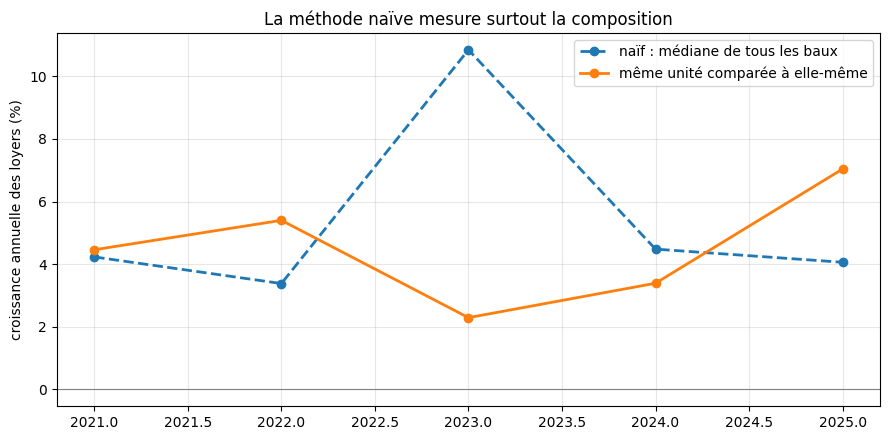

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4.5))
yrs = range(2021, 2026)
ax.plot(yrs, naive.loc[yrs, "yoy_pct"], "o--", label="naïf : médiane de tous les baux", lw=2)
ax.plot(yrs, honest.loc[yrs, "median"], "o-", label="même unité comparée à elle-même", lw=2)
ax.axhline(0, color="grey", lw=0.8)
ax.set_ylabel("croissance annuelle des loyers (%)")
ax.set_title("La méthode naïve mesure surtout la composition")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()



## 5. Loyer contractuel n'est pas loyer perçu

`sRent` est ce que le bail indique. `sRentEffective` est ce qu'Équinoxe a réellement
perçu après les mois gratuits, le stationnement gratuit et les casiers gratuits. Les concessions sont maintenant
la norme, et elles progressent.

In [3]:
conc = (leases[leases.year.between(2021, 2025)]
        .groupby("year")
        .agg(leases=("sRent", "size"),
             pct_with_concession=("sConcession", lambda s: s.mean() * 100),
             median_contracted=("sRent", "median"),
             median_effective=("sRentEffective", "median")))
conc["gap_pct"] = ((conc.median_effective / conc.median_contracted - 1) * 100)
conc.round(2)

NameError: name 'leases' is not defined

In [12]:
# La concession change-t-elle l'évolution, ou seulement le niveau?
eff = same_unit_growth(leases, price_col="sRentEffective")
compare = pd.DataFrame({
    "contracted": honest["median"],
    "effective":  eff[eff.year.between(2021, 2025)].groupby("year").growth_pct.median(),
}).round(2)
compare

,contracted,effective
year,,
2021,4.46,3.54
2022,5.40,4.59
2023,2.29,2.02
2024,3.39,1.77
2025,7.04,3.58


Ces deux colonnes évoluent de près jusqu'en 2023 - à moins
d'un point l'une de l'autre - puis elles divergent : en 2025, la croissance contractuelle est de
7,0 % alors que la croissance effective est de 3,6 %. L'écart de *niveau* du tableau précédent
se creuse tout au long de la période.

Elles répondent à des questions différentes, et l'année où elles se séparent est celle où les concessions
deviennent plus importantes plutôt que simplement plus fréquentes. Si vous pouvez expliquer ce que cette séparation signifie pour un
propriétaire - et laquelle des deux vous citeriez à un propriétaire - vous comprenez les données
mieux que la plupart des équipes.

## 6. Les renouvellements ne se comportent pas comme les relocations

`sRenewal = 1`, c'est un locataire en place qui renouvelle. `sRenewal = 0`, c'est une unité
qui se libère et qui est relouée au prix du marché. Au Québec, ces deux cas sont régis par
des règles différentes, et l'écart entre les deux est toute la raison pour laquelle un propriétaire s'intéresse
à ce chiffre. Remarquez que l'écart change de camp au cours de la période : les renouvellements mènent en 2022, les relocations en 2025.

In [13]:
split = (pairs[pairs.year.between(2022, 2025)]
         .groupby(["year", "sRenewal"])
         .growth_pct.agg(pairs="size", median="median").round(2)
         .unstack("sRenewal"))
split.columns = [f"{a}_{'renewal' if b else 'turnover'}" for a, b in split.columns]
split

,pairs_turnover,pairs_renewal,median_turnover,median_renewal
year,,,,
2022,126,226,4.22,5.69
2023,177,239,1.85,2.58
2024,276,422,4.85,2.94
2025,307,473,8.98,6.41


## 7. À vous de jouer

Tout ce qui précède est descriptif. Rien de tout ça n'est une prévision, et 2026 n'est pas dans
ce jeu. Ce qui reste, c'est le vrai travail :

**a) Décidez à quelle question vous répondez.** « La hausse de loyer de l'année », ce sont en fait
plusieurs chiffres différents : même unité contractuel, même unité effectif, renouvellements
seulement, relocations seulement, portefeuille combiné. Ils ne concordent pas. Choisissez-en un, nommez-le dans
votre rapport et justifiez votre choix.

**b) Intégrez des données publiques.**

- **Enquête sur les logements locatifs de la SCHL** : loyers et taux d'inoccupation par nombre de chambres pour les
  RMR de Montréal et d'Ottawa, ainsi que la répartition entre logements ayant changé de locataire ou non, qui correspond
  directement à `sRenewal`
- **IPC de Statistique Canada**, composante loyers, Québec et Ontario
- **Tribunal administratif du logement** : les paramètres annuels d'augmentation de loyer au Québec.
  Cinq des six immeubles y sont assujettis
- **Taux légal d'augmentation des loyers en Ontario** : s'applique à l'immeuble The Met, selon
  des règles différentes. N'appliquez pas le plafond d'une province à l'autre

Utilisez la série externe sur l'inoccupation comme *contexte* pour l'orientation des loyers. N'essayez pas
de la transposer en taux d'occupation propre à ce portefeuille - voir la note de la section 2.

**c) Faites une prévision.** Une extrapolation de tendance est un point de départ légitime. Une approche
qui concilie la tendance interne avec le marché externe est meilleure. Énoncez
vos hypothèses.

**e) Misez sur le raisonnement et faites de votre mieux.** Si votre méthode atteint une précision de 95 % et que quelqu'un d'autre obtient 96 %, ça ne veut pas dire que l'autre a gagné. Vous êtes évalué davantage sur la technique que sur le résultat. Les résultats comptent, mais sans un raisonnement constamment démontré derrière chaque choix, même 99 % ne veut rien dire. Nous devons voir une logique claire derrière vos décisions. Note : vous devez **TOUJOURS** expliquer une étape importante, même si ça vous semble inutile ou peu naturel.

## 8. Définition de la hausse de loyer étudiée

Avant d'élaborer une prévision pour 2026, nous devons définir précisément ce que nous entendons par « hausse de loyer ». Une comparaison directe des loyers moyens ou médians du portefeuille entre deux années peut être trompeuse lorsque la composition du portefeuille change. Nous privilégions donc une mesure à unité constante, où chaque logement est comparé à son propre bail précédent.

Notre indicateur principal sera la **croissance médiane annualisée du loyer effectif à unité constante**, pour le portefeuille combiné. Une unité est identifiée par la combinaison `sPropCode + sUnitCode`, qui permet de suivre le même logement dans le temps.

Nous utilisons principalement `sRentEffective` plutôt que le seul loyer contractuel `sRent`, puisque le loyer effectif reflète l'impact économique des concessions accordées au locataire. Nous conservons toutefois les deux mesures afin de distinguer la croissance contractuelle de la croissance effectivement réalisée après concessions.

Les renouvellements (`sRenewal = 1`) et les relocations (`sRenewal = 0`) seront analysés séparément avant l'agrégation, puisqu'ils répondent à des dynamiques de marché et à des contraintes réglementaires différentes.

La prévision 2026 sera construite en quatre étapes :

1. mesurer correctement la croissance historique à unité constante ;
2. expliquer les différences entre loyers contractuels et effectifs ainsi qu'entre renouvellements et relocations ;
3. confronter les tendances internes aux données de marché et aux cadres réglementaires du Québec et de l'Ontario ;
4. valider la méthode par des backtests sur 2023, 2024 et 2025 avant de l'appliquer à 2026.

Les données fournies constituent un extrait représentatif et non le rôle de loyers complet du portefeuille. Nous n'en déduisons donc aucun taux d'occupation, d'inoccupation ou d'absorption propre au portefeuille Équinoxe.

## 9. Audit et validation des données
Nous commençons par examiner la structure et la cohérence des quatre tables mises à disposition, et ce avant toute prévision. Il s'agit de saisir le niveau de granularité propre à chacune, de repérer les clés qui permettront de les relier entre elles et de contrôler la couverture des données dont nous disposons. 

Ce contrôle intervient délibérément en amont de toute modélisation : bâtir une méthode de prévision élaborée sur des unités mal appariées ou des variables mal interprétées donnerait des résultats plausibles sur le plan numérique, mais faux sur le plan économique.

In [14]:
tables = {
    "listings": listings,
    "leases": leases,
    "concessions": concessions,
    "asking": asking
}

audit_rows = []

for name, df in tables.items():
    audit_rows.append({
        "table": name,
        "n_rows": len(df),
        "n_columns": df.shape[1],
        "n_unique_units": (
            df["hUnit"].nunique()
            if "hUnit" in df.columns
            else np.nan
        ),
        "n_properties": (
            df["sPropCode"].nunique()
            if "sPropCode" in df.columns
            else np.nan
        )
    })

audit = pd.DataFrame(audit_rows)
audit

,table,n_rows,n_columns,n_unique_units,n_properties
0,listings,1061,29,1061,9
1,leases,4302,36,1061,9
2,concessions,3560,18,1014,9
3,asking,3857,15,1061,9


### Interprétation de l'audit

Les quatre tables n'ont pas la même granularité.

La table `listings` contient 1 061 lignes pour 1 061 unités distinctes, ce qui correspond à une photographie des unités présentes dans l'extrait.

La table `leases` contient 4 302 observations pour ces mêmes 1 061 unités. Une unité peut donc apparaître plusieurs fois, ce qui est cohérent avec un historique de baux successifs.

La table `asking` contient également plusieurs observations par unité, permettant de suivre l'évolution des loyers demandés dans le temps.

La table `concessions` couvre 1 014 unités sur les 1 061 observées dans les autres tables. L'absence d'une unité dans cette table n'est pas interprétée automatiquement comme une absence de concession : la structure de cette table est examinée séparément avant toute conclusion.

Enfin, neuf valeurs distinctes de `sPropCode` sont présentes alors que le défi décrit six immeubles. Nous vérifions donc la relation entre codes de propriété Yardi et bâtiments physiques avant toute agrégation.

### 9.1 Validation de l'identifiant d'une unité
Dans Yardi, chaque appartement a un identifiant spécial appelé hUnit, pendant que sUnitCode est plus lié au code utilisé pour le travail. Cependant, un même sUnitCode peut être utilisé dans plusieurs bâtiments.

Pour éviter toute confusion, on fait en sorte que la combinaison sPropCode et sUnitCode ne renvoie qu'à un seul hUnit. C'est cette combinaison qui nous aide ensuite à suivre le même appartement et à comparer ses contrats au fil du temps.

In [15]:
unit_mapping = (
    leases[["hUnit", "sPropCode", "sUnitCode"]]
    .drop_duplicates()
)

n_hunits = unit_mapping["hUnit"].nunique()

n_business_keys = (
    unit_mapping[["sPropCode", "sUnitCode"]]
    .drop_duplicates()
    .shape[0]
)

max_hunits_per_business_key = (
    unit_mapping
    .groupby(["sPropCode", "sUnitCode"])["hUnit"]
    .nunique()
    .max()
)

max_business_keys_per_hunit = (
    unit_mapping
    .groupby("hUnit")
    .size()
    .max()
)

print("hUnit uniques :", n_hunits)
print("sPropCode + sUnitCode uniques :", n_business_keys)
print("Maximum de hUnit par clé métier :", max_hunits_per_business_key)
print("Maximum de clés métier par hUnit :", max_business_keys_per_hunit)

hUnit uniques : 1061
sPropCode + sUnitCode uniques : 1061
Maximum de hUnit par clé métier : 1
Maximum de clés métier par hUnit : 1


### Interprétation

L'extrait contient 1 061 identifiants techniques `hUnit` et exactement 1 061 combinaisons distinctes `sPropCode + sUnitCode`.

Aucune combinaison `sPropCode + sUnitCode` ne correspond à plusieurs `hUnit`, et aucun `hUnit` ne correspond à plusieurs combinaisons métier. Dans les données fournies, la correspondance est donc univoque dans les deux sens.

Nous pouvons ainsi utiliser `sPropCode + sUnitCode` comme clé métier lisible pour suivre une même unité au fil de ses baux, tout en conservant `hUnit` comme identifiant technique de contrôle.

### 9.2 Propriétés, immeubles et segmentation du portefeuille

L'audit fait apparaître neuf valeurs distinctes de `sPropCode`, alors que le défi décrit un portefeuille de six immeubles.

Avant d'effectuer des analyses par propriété, nous devons donc vérifier à quoi correspondent réellement les différents codes Yardi. Un code de propriété peut représenter une entité de gestion, une phase ou une subdivision qui ne correspond pas nécessairement à un immeuble physique distinct.

Nous examinons les variables descriptives associées à chaque `sPropCode` afin d'éviter de confondre une structure administrative de Yardi avec la structure immobilière réelle du portefeuille.

In [16]:
# Colonnes disponibles pouvant décrire la propriété ou l'immeuble
property_cols = [
    col for col in listings.columns
    if any(keyword in col.lower() for keyword in [
        "prop", "site", "building", "address", "city", "state", "province"
    ])
]

print("Colonnes potentiellement liées à la propriété :")
print(property_cols)

Colonnes potentiellement liées à la propriété :
['hProperty', 'hBuilding', 'sPropCode', 'sBuilding', 'sCity', 'sState', 'sPropType', 'sSite']


#### 9.2.1 Correspondance entre propriétés Yardi et immeubles physiques

Le nombre de `sPropCode` est supérieur au nombre d'immeubles indiqué dans le défi. Nous vérifions donc si plusieurs codes de propriété Yardi peuvent être associés au même bâtiment physique.

Cette distinction est importante : `sPropCode` représente une propriété dans la structure de gestion Yardi, alors que `sBuilding` représente le bâtiment de manière plus directement interprétable. Une agrégation effectuée au mauvais niveau pourrait artificiellement fragmenter un même immeuble en plusieurs groupes.

In [17]:
mapping_cols = [
    col for col in [
        "hProperty",
        "hBuilding",
        "sPropCode",
        "sBuilding",
        "sCity",
        "sState",
        "sSite"
    ]
    if col in listings.columns
]

property_mapping = (
    listings[mapping_cols]
    .drop_duplicates()
    .sort_values(["sBuilding", "sPropCode"])
    .reset_index(drop=True)
)

property_mapping

,hProperty,hBuilding,sPropCode,sBuilding,sCity,sState,sSite
0,101,10,dj1,Daniel-Johnson,Laval,Quebec,daniel-johnson
1,102,10,dj2,Daniel-Johnson,Laval,Quebec,daniel-johnson
2,100,11,carlyle,Le Carlyle,Mont-Royal,Quebec,le-carlyle
3,103,12,levesque,Levesque,Laval,Quebec,levesque
4,105,13,stelz1,Saint-Elzear,Laval,Quebec,saint-elzear
5,106,13,stelz2,Saint-Elzear,Laval,Quebec,saint-elzear
6,107,13,stelz3,Saint-Elzear,Laval,Quebec,saint-elzear
7,104,14,metcalfe,The Met,Ottawa,Ontario,the-met
8,108,15,wsp1,Westpark,Pointe-Claire,Quebec,westpark


#### 9.2.2 Taille des différents segments dans l'extrait

Nous comptons ensuite le nombre d'unités distinctes associé à chaque combinaison propriété-immeuble. Cela permet de comprendre le poids relatif des différents segments dans le portefeuille et d'identifier les éventuelles subdivisions administratives d'un même bâtiment.

In [18]:
property_summary = (
    listings
    .groupby(
        ["sPropCode", "sBuilding", "sCity", "sState"],
        dropna=False
    )
    .agg(
        n_units=("hUnit", "nunique")
    )
    .reset_index()
    .sort_values(["sBuilding", "sPropCode"])
)

property_summary

,sPropCode,sBuilding,sCity,sState,n_units
1,dj1,Daniel-Johnson,Laval,Quebec,58
2,dj2,Daniel-Johnson,Laval,Quebec,76
0,carlyle,Le Carlyle,Mont-Royal,Quebec,192
3,levesque,Levesque,Laval,Quebec,84
5,stelz1,Saint-Elzear,Laval,Quebec,106
6,stelz2,Saint-Elzear,Laval,Quebec,122
7,stelz3,Saint-Elzear,Laval,Quebec,133
4,metcalfe,The Met,Ottawa,Ontario,124
8,wsp1,Westpark,Pointe-Claire,Quebec,166


#### 9.2.3 Poids des immeubles dans l'extrait

Le nombre d'unités observées varie fortement d'un bâtiment à l'autre. Nous calculons donc la part de chaque immeuble dans l'extrait afin de mieux comprendre les effets de composition potentiels.

Cette mesure décrit uniquement la structure de l'échantillon fourni. Elle ne doit pas être interprétée comme la part réelle de chaque immeuble dans le portefeuille complet d'Équinoxe.

Elle sera notamment utile pour déterminer si une variation de la médiane globale provient réellement d'une hausse des loyers ou d'un changement dans la composition des observations disponibles.

In [19]:
building_summary = (
    listings
    .groupby(["sBuilding", "sCity", "sState"], dropna=False)
    .agg(
        n_units=("hUnit", "nunique"),
        n_property_codes=("sPropCode", "nunique")
    )
    .reset_index()
)

building_summary["extract_share_pct"] = (
    building_summary["n_units"]
    / building_summary["n_units"].sum()
    * 100
)

building_summary = (
    building_summary
    .sort_values("n_units", ascending=False)
    .reset_index(drop=True)
)

building_summary.round(1)

,sBuilding,sCity,sState,n_units,n_property_codes,extract_share_pct
0,Saint-Elzear,Laval,Quebec,361,3,34.0
1,Le Carlyle,Mont-Royal,Quebec,192,1,18.1
2,Westpark,Pointe-Claire,Quebec,166,1,15.6
3,Daniel-Johnson,Laval,Quebec,134,2,12.6
4,The Met,Ottawa,Ontario,124,1,11.7
5,Levesque,Laval,Quebec,84,1,7.9


### Interprétation de la structure du portefeuille

Les neuf valeurs de `sPropCode` correspondent en réalité à six bâtiments distincts dans l'extrait fourni, ce qui est cohérent avec la description du défi.

Deux propriétés Yardi (`dj1` et `dj2`) appartiennent au bâtiment Daniel-Johnson, tandis que trois propriétés (`stelz1`, `stelz2` et `stelz3`) appartiennent à Saint-Elzear. Les autres bâtiments correspondent chacun à un seul `sPropCode`.

Cette distinction influence le niveau d'analyse retenu :

- `sPropCode + sUnitCode` reste utilisé pour identifier une unité de manière unique dans le temps ;
- `sBuilding` est utilisé pour les analyses agrégées par immeuble physique.

Ainsi, nous évitons de traiter artificiellement plusieurs subdivisions administratives Yardi comme des immeubles différents.

### 9.3 Couverture temporelle

Une prévision historique n'est valide que si elle utilise des informations qui étaient réellement disponibles au moment où la prévision aurait été produite.

Nous examinons donc les colonnes de dates présentes dans chaque table afin de déterminer la période couverte et, plus tard, de pouvoir empêcher toute fuite d'information future dans les backtests.

In [20]:
for name, df in tables.items():
    date_like_cols = [
        col for col in df.columns
        if any(keyword in col.lower() for keyword in [
            "date", "start", "end", "move", "term"
        ])
    ]
    
    print(f"\n{name.upper()}")
    print(date_like_cols)


LISTINGS
['sLeaseTerm']

LEASES
['sLeaseTerm', 'sSignDate', 'sTermMonths', 'sTermSeq']

CONCESSIONS
['sDateFrom', 'sDateTo']

ASKING
['date']


#### 9.3.1 Dates réellement utilisables

La recherche automatique des colonnes temporelles a également détecté plusieurs champs contenant le mot `Term`. Ceux-ci ne représentent pas nécessairement des dates : `sLeaseTerm` décrit le type de bail, `sTermMonths` sa durée et `sTermSeq` sa position dans la séquence des baux.

Pour les baux, nous distinguons trois dates importantes :

- `sSignDate` : date à laquelle le bail est signé ;
- `sLeaseFrom` : date de début du bail ;
- `sLeaseTo` : date de fin du bail.

La date `sLeaseFrom` sert à attribuer un bail à une année de croissance, tandis que `sSignDate` sera particulièrement importante pour déterminer quelles informations étaient réellement disponibles au moment d'un backtest.

Pour les concessions, `sDateFrom` et `sDateTo` décrivent leur période d'application. Elles ne doivent pas être interprétées automatiquement comme la date à laquelle l'information était connue.

Cette distinction permet d'éviter de traiter une durée, un numéro de séquence ou une période future comme une information disponible au moment de la prévision.

In [21]:
temporal_fields = {
    "leases": [
        "sSignDate",
        "sLeaseFrom",
        "sLeaseTo"
    ],
    "concessions": [
        "sDateFrom",
        "sDateTo"
    ],
    "asking": [
        "date"
    ]
}

temporal_audit = []

for table_name, columns in temporal_fields.items():
    df = tables[table_name]

    for col in columns:
        parsed = pd.to_datetime(df[col], errors="coerce")

        temporal_audit.append({
            "table": table_name,
            "column": col,
            "first_date": parsed.min(),
            "last_date": parsed.max(),
            "n_valid_dates": parsed.notna().sum(),
            "n_invalid_or_missing": parsed.isna().sum()
        })

temporal_audit = pd.DataFrame(temporal_audit)
temporal_audit

,table,column,first_date,last_date,n_valid_dates,n_invalid_or_missing
0,leases,sSignDate,2016-10-26,2025-12-27,4302,0
1,leases,sLeaseFrom,2017-01-01,2025-12-31,4302,0
2,leases,sLeaseTo,2017-09-29,2027-11-05,4302,0
3,concessions,sDateFrom,2017-01-01,2027-03-01,3560,0
4,concessions,sDateTo,2017-08-29,2027-05-01,3560,0
5,asking,date,2016-10-01,2025-12-01,3857,0


### Interprétation de la couverture temporelle

L'historique des dates de signature et de début de bail couvre plusieurs années avant les périodes de backtest, ce qui permet de reconstruire des prévisions historiques sur 2023, 2024 et 2025.

Certaines dates de fin de bail (`sLeaseTo`) et certaines périodes de concessions s'étendent au-delà de 2025. Leur présence ne signifie pas nécessairement qu'une information future a été utilisée : la date de fin d'un bail peut être connue dès sa signature.

Lors des backtests, `sSignDate` sera donc utilisée pour déterminer si un bail était déjà connu à la date de prévision, tandis que `sLeaseFrom` servira à déterminer l'année économique à laquelle le bail appartient.

Les dates de concessions sont traitées plus prudemment, puisqu'aucun identifiant de bail commun ne permet de les rattacher directement aux baux.

### 9.4 Séquence des baux d'une même unité

La variable `sTermSeq` semble représenter la position d'un bail dans l'historique d'une unité. Nous vérifions sa cohérence avec les dates de début de bail.

Cette variable ne sera pas utilisée aveuglément comme identifiant temporel, mais elle peut servir de contrôle lors de l'appariement entre un bail et son bail précédent.

In [22]:
lease_sequence_check = (
    leases[
        [
            "hUnit",
            "sPropCode",
            "sUnitCode",
            "sSignDate",
            "sLeaseFrom",
            "sTermSeq",
            "sRenewal",
            "sRent",
            "sRentEffective"
        ]
    ]
    .sort_values(["hUnit", "sLeaseFrom"])
)

lease_sequence_check.groupby("hUnit")[
    "sTermSeq"
].count().describe()

count    1061.000000
mean        4.054665
std         2.518765
min         1.000000
25%         2.000000
50%         3.000000
75%         7.000000
max         8.000000
Name: sTermSeq, dtype: float64

#### 9.4.1 Validation globale de l'ordre des baux

Les premières observations indiquent que `sTermSeq` semble suivre l'ordre chronologique des baux d'une même unité. Une inspection de quelques lignes ne suffit toutefois pas à valider cette hypothèse sur l'ensemble des données.

Nous reconstruisons donc indépendamment l'ordre des baux à partir de `sLeaseFrom`, puis nous comparons cette séquence à `sTermSeq`.

Nous utilisons `sLeaseFrom` plutôt que `sSignDate` pour ce contrôle, car `sTermSeq` décrit la succession des périodes de bail, alors qu'un bail peut être signé plusieurs semaines ou plusieurs mois avant son entrée en vigueur.

In [23]:
sequence_check = leases[
    ["hUnit", "sLeaseFrom", "sTermSeq"]
].copy()

sequence_check = sequence_check.sort_values(
    ["hUnit", "sLeaseFrom"]
)

sequence_check["computed_seq"] = (
    sequence_check
    .groupby("hUnit")
    .cumcount()
    + 1
)

sequence_check["seq_matches"] = (
    sequence_check["sTermSeq"]
    == sequence_check["computed_seq"]
)

sequence_match_pct = sequence_check["seq_matches"].mean() * 100
n_sequence_mismatches = (~sequence_check["seq_matches"]).sum()

print(
    "Correspondance entre sTermSeq et l'ordre chronologique :",
    f"{sequence_match_pct:.2f}%"
)

print(
    "Nombre d'incohérences :",
    n_sequence_mismatches
)

Correspondance entre sTermSeq et l'ordre chronologique : 100.00%
Nombre d'incohérences : 0


### Interprétation de la séquence des baux

La variable `sTermSeq` correspond parfaitement à l'ordre chronologique des baux reconstruit à partir de `sLeaseFrom` : 100 % des 4 302 observations sont cohérentes et aucune incohérence n'est détectée.

Nous pouvons donc considérer `sTermSeq` comme un indicateur fiable de la position d'un bail dans l'historique d'une unité. Pour les calculs de croissance, nous continuons néanmoins à utiliser les dates réelles afin de mesurer précisément l'écart temporel entre deux baux et d'annualiser la variation lorsque nécessaire.

Cette validation renforce la fiabilité de l'appariement entre un bail et son bail précédent.

### 9.5 Liaison entre les baux et les concessions

La table `leases` contient déjà le loyer contractuel (`sRent`), le loyer effectif (`sRentEffective`) et un indicateur signalant la présence d'une concession (`sConcession`).

La table `concessions` fournit un niveau de détail supplémentaire sur les avantages accordés aux locataires. Avant de l'intégrer à l'analyse, nous devons cependant déterminer comment ses observations peuvent être reliées aux baux.

Une jointure basée uniquement sur l'unité serait risquée : une même unité peut avoir plusieurs baux et plusieurs concessions au fil du temps. Nous examinons donc d'abord les colonnes communes entre les deux tables afin de déterminer si un identifiant de bail est disponible ou si une logique temporelle sera nécessaire.

In [24]:
common_lease_concession_cols = sorted(
    set(leases.columns)
    .intersection(concessions.columns)
)

common_lease_concession_cols

['hBuilding',
 'hProperty',
 'hUnit',
 'sBeds',
 'sBuilding',
 'sCity',
 'sFloor',
 'sPropCode',
 'sSite',
 'sSqft',
 'sState',
 'sUnitCode']

### Interprétation de la liaison entre baux et concessions

Les deux tables partagent des identifiants d'unité et des caractéristiques du logement, mais aucun identifiant propre au bail.

Une jointure directe sur `hUnit` ou sur `sPropCode + sUnitCode` créerait donc un risque de relation plusieurs-à-plusieurs : une même unité peut avoir plusieurs baux et plusieurs concessions au cours de son historique.

Nous n'effectuons donc pas de jointure automatique entre `leases` et `concessions` à ce stade.

Pour mesurer la croissance des loyers, nous privilégions `sRentEffective`, déjà disponible directement dans la table `leases`. La table `concessions` sera utilisée pour comprendre la nature, la fréquence et l'intensité des avantages accordés aux locataires. Si une association détaillée concession-bail devient nécessaire, elle devra être construite à partir des périodes temporelles et validée avant utilisation.

### 9.6 Nature et intensité des concessions

La présence d'une concession ne suffit pas à mesurer son impact économique. Un stationnement offert pendant douze mois, un mois de loyer gratuit et un crédit promotionnel ponctuel sont des avantages de nature différente.

Nous examinons donc les codes de concession, leur fréquence, leur montant et leur durée avant de décider comment les interpréter.

Cette étape est particulièrement importante pour `PromoPay`, dont la description source peut être trompeuse. Nous évitons donc d'imposer une interprétation comptable avant d'avoir observé sa distribution réelle.

In [25]:
concession_profile = (
    concessions
    .groupby(
        ["sChargeCode", "sChargeDesc"],
        dropna=False
    )
    .agg(
        n_records=("hUnit", "size"),
        n_units=("hUnit", "nunique"),
        median_amount=("sAmount", "median"),
        mean_amount=("sAmount", "mean"),
        min_amount=("sAmount", "min"),
        max_amount=("sAmount", "max"),
        median_months=("sMonths", "median"),
        mean_months=("sMonths", "mean")
    )
    .reset_index()
    .sort_values("n_records", ascending=False)
)

concession_profile.round(2)

,sChargeCode,sChargeDesc,n_records,n_units,median_amount,mean_amount,min_amount,max_amount,median_months,mean_months
2,PromoPay,Promo - Payable in the future,1494,781,-1356.60,-1566.82,-10927.95,-12.68,1.0,1.12
6,freepark,Free Parking,1006,646,-150.50,-217.88,-1739.90,-1.99,12.0,8.95
0,Freeothe,Free other,570,436,-153.49,-217.67,-1587.27,-2.90,12.0,8.98
5,freelock,Free Locker,175,166,-139.35,-204.85,-1757.60,-3.62,12.0,9.00
7,freerent,Free rent,166,152,-129.30,-203.82,-1000.52,-2.34,12.0,9.25
1,Indem,Client indemnity,69,66,-149.26,-221.71,-1057.40,-4.27,12.0,9.01
4,freeappl,Free Appliances,44,39,-143.58,-180.18,-1015.47,-11.61,12.0,9.68
3,Referenc,Referencing program,36,35,-148.26,-195.56,-627.32,-1.79,12.0,9.78


#### 9.6.1 Convention de signe des montants

Avant d'additionner ou de comparer les concessions, nous vérifions la convention de signe utilisée dans les données Yardi.

Un montant négatif peut représenter un crédit ou une réduction accordée au locataire. Nous vérifions cette convention directement dans les données plutôt que de la supposer.

In [26]:
concession_sign_check = pd.DataFrame({
    "negative": [(concessions["sAmount"] < 0).sum()],
    "zero": [(concessions["sAmount"] == 0).sum()],
    "positive": [(concessions["sAmount"] > 0).sum()],
    "total": [len(concessions)]
})

concession_sign_check

,negative,zero,positive,total
0,3560,0,0,3560


### Interprétation de la convention de signe

Les 3 560 observations de la table `concessions` présentent toutes un `sAmount` strictement négatif. Dans cet extrait, le signe négatif correspond donc systématiquement à une valeur accordée au bénéfice du locataire.

Nous conservons le signe d'origine pour respecter la convention comptable de la source. Lorsque nous voudrons comparer l'intensité économique des concessions, nous pourrons utiliser leur valeur absolue afin d'exprimer la taille du crédit de manière positive.

Cette vérification évite notamment d'interpréter à tort une concession de -150 $ comme une perte ou une anomalie de données.

#### 9.6.2 Vérification spécifique de `PromoPay`

`PromoPay` se distingue nettement des autres types de concessions. Son montant est beaucoup plus élevé, tandis que sa durée enregistrée est généralement beaucoup plus courte.

Cette structure suggère qu'il ne doit pas être interprété comme un frais mensuel récurrent. Nous examinons sa distribution plus précisément avant de décider de son rôle dans l'analyse.

Notre objectif n'est pas de reconstruire immédiatement le loyer effectif à partir de cette variable, puisque `sRentEffective` est déjà disponible dans la table des baux. Cette analyse sert plutôt à comprendre le mécanisme économique qui explique l'écart entre loyer contractuel et loyer effectif.

In [27]:
promopay = concessions[
    concessions["sChargeCode"] == "PromoPay"
].copy()

promopay_summary = (
    promopay[["sAmount", "sMonths"]]
    .describe(
        percentiles=[0.10, 0.25, 0.50, 0.75, 0.90]
    )
    .round(2)
)

promopay_summary

,sAmount,sMonths
count,1494.00,1494.00
mean,-1566.82,1.12
std,1115.06,0.32
min,-10927.95,1.00
10%,-2909.69,1.00
25%,-2213.72,1.00
50%,-1356.60,1.00
75%,-761.61,1.00
90%,-330.98,2.00
max,-12.68,2.00


#### 9.6.3 Durée d'application de `PromoPay`

La médiane seule indique une durée d'un mois, mais nous voulons vérifier si ce comportement est dominant ou s'il masque plusieurs types de promotions.

Nous examinons donc directement la fréquence de chaque valeur de `sMonths`.

In [28]:
promopay_month_distribution = (
    promopay["sMonths"]
    .value_counts()
    .sort_index()
    .rename_axis("months")
    .reset_index(name="n_records")
)

promopay_month_distribution["share_pct"] = (
    promopay_month_distribution["n_records"]
    / promopay_month_distribution["n_records"].sum()
    * 100
)

promopay_month_distribution.round(2)

,months,n_records,share_pct
0,1.0,1318,88.22
1,2.0,176,11.78


#### 9.6.4 Interprétation de `PromoPay`

`PromoPay` présente un comportement nettement différent des autres catégories de concessions.

Son montant médian est de -1 356,60 $, avec une dispersion importante des montants. En parallèle, 88,22 % des observations sont enregistrées sur un seul mois et les 11,78 % restantes sur deux mois.

Ces résultats ne sont pas compatibles avec l'interprétation de `PromoPay` comme un frais mensuel récurrent. Dans cet extrait, la variable se comporte davantage comme un crédit promotionnel ponctuel ou de courte durée.

Nous ne cherchons toutefois pas à reconstruire directement `sRentEffective` à partir de cette table. La table `leases` fournit déjà le loyer effectif associé à chaque bail, sans nécessiter une jointure potentiellement ambiguë avec les concessions.

La table `concessions` est donc utilisée principalement pour comprendre les mécanismes économiques expliquant l'écart entre loyer contractuel et loyer effectif.

## 10. Effet de composition : d'où vient la hausse apparente ?

La comparaison des médianes annuelles du portefeuille produit une hausse apparente de 10,85 % en 2023, alors que la croissance à unité constante n'est que de 2,29 %.

Cet écart suggère qu'une grande partie de la variation observée ne provient pas de l'augmentation du loyer d'un même logement, mais d'un changement dans la composition des baux observés.

Nous cherchons maintenant à identifier les principales sources de cet effet de composition. Nous examinons d'abord la répartition des baux entre les différents immeubles au fil du temps, puis nous construisons un diagnostic où l'univers d'immeubles est maintenu constant.

### 10.1 Évolution du mix d'immeubles

Les immeubles du portefeuille n'ont pas tous été introduits dans l'historique au même moment et leurs niveaux de loyers diffèrent fortement.

Si un immeuble relativement cher représente soudainement une part importante des baux d'une année, la médiane globale peut augmenter même sans forte hausse du loyer des logements déjà présents.

Nous calculons donc, pour chaque année, la proportion des baux provenant de chaque immeuble.

In [29]:
building_mix = (
    pd.crosstab(
        window["year"],
        window["sBuilding"],
        normalize="index"
    )
    * 100
)

building_mix = building_mix.round(1)

building_mix.loc[2021:2025]

sBuilding,Daniel-Johnson,Le Carlyle,Levesque,Saint-Elzear,The Met,Westpark
year,,,,,,
2021,15.8,0.0,23.3,60.9,0.0,0.0
2022,28.4,0.0,19.4,52.1,0.0,0.0
2023,19.3,22.4,12.0,31.3,15.0,0.0
2024,15.1,21.6,9.3,23.8,14.2,16.0
2025,13.6,19.3,8.0,30.1,12.5,16.5


### Interprétation du mix d'immeubles

La composition des baux change fortement à partir de 2023.

En 2022, les observations proviennent uniquement des trois immeubles historiques : Daniel-Johnson, Levesque et Saint-Elzear. En 2023, Le Carlyle représente déjà 22,4 % des baux observés et The Met 15,0 %, soit 37,4 % des observations à eux deux.

En 2024, l'arrivée de Westpark accentue encore ce changement : Le Carlyle, The Met et Westpark représentent ensemble plus de la moitié des baux observés.

La médiane annuelle du portefeuille compare donc des ensembles de logements dont la composition est très différente d'une année à l'autre. Une variation de cette médiane ne peut pas être interprétée directement comme la hausse du loyer d'un logement existant.

### 10.2 Diagnostic à univers d'immeubles constant

Pour isoler l'effet créé par l'arrivée de nouveaux immeubles, nous construisons un diagnostic complémentaire.

Nous identifions les bâtiments qui étaient déjà présents avant 2023 et recalculons la médiane des loyers uniquement sur cet univers constant. Cette mesure n'est pas notre indicateur final de croissance — elle ne remplace pas la comparaison à unité constante — mais elle permet de quantifier l'importance du changement de composition entre immeubles.

Si la hausse de la médiane diminue fortement lorsque l'univers des bâtiments est maintenu constant, cela constitue une indication directe qu'une partie importante de la hausse globale provient du mix du portefeuille.

In [30]:
first_year_by_building = (
    window
    .groupby("sBuilding")["year"]
    .min()
)

buildings_present_before_2023 = (
    first_year_by_building[
        first_year_by_building < 2023
    ]
    .index
)

stable_building_sample = window[
    window["sBuilding"].isin(
        buildings_present_before_2023
    )
]

portfolio_median = (
    window
    .groupby("year")["sRent"]
    .median()
)

stable_building_median = (
    stable_building_sample
    .groupby("year")["sRent"]
    .median()
)

composition_diagnostic = pd.DataFrame({
    "portfolio_median": portfolio_median,
    "stable_buildings_median": stable_building_median
})

composition_diagnostic["portfolio_growth_pct"] = (
    composition_diagnostic["portfolio_median"]
    .pct_change()
    * 100
)

composition_diagnostic["stable_buildings_growth_pct"] = (
    composition_diagnostic["stable_buildings_median"]
    .pct_change()
    * 100
)

composition_diagnostic.loc[2021:2025].round(2)

,portfolio_median,stable_buildings_median,portfolio_growth_pct,stable_buildings_growth_pct
year,,,,
2021,1850.0,1850.0,4.23,4.23
2022,1912.5,1912.5,3.38,3.38
2023,2120.0,1927.5,10.85,0.78
2024,2215.0,1995.0,4.48,3.50
2025,2305.0,2090.0,4.06,4.76


### Interprétation du diagnostic à univers constant

Le diagnostic confirme l'importance de l'effet de composition.

En 2023, la médiane de l'ensemble des baux augmente de 10,85 %. Lorsque nous limitons l'analyse aux immeubles déjà présents avant 2023, cette hausse n'est plus que de 0,78 %.

L'écart de 10,07 points entre les deux mesures montre que la forte hausse apparente de 2023 est largement associée au changement de composition entre immeubles, notamment à l'arrivée de bâtiments dont le niveau de loyer est différent.

Cette mesure à univers d'immeubles constant reste toutefois imparfaite : même à l'intérieur des mêmes bâtiments, la composition des logements loués peut changer selon la taille, le nombre de chambres ou le type d'unité. C'est pourquoi notre mesure principale reste la comparaison à unité constante.

### 10.3 Effet de mix à l'intérieur des immeubles

Maintenir les mêmes immeubles ne suffit pas à garantir une composition identique des logements observés.

D'une année à l'autre, un bâtiment peut générer davantage de baux pour des studios, des une chambre ou des logements de grande superficie. Comme ces catégories n'ont pas les mêmes niveaux de loyer ni les mêmes loyers au pied carré, leur poids relatif peut modifier la médiane globale sans qu'un logement donné ait subi la même variation.

Nous examinons donc l'évolution du nombre de chambres, de la superficie et du loyer au pied carré des baux observés.

In [31]:
unit_mix_by_year = (
    window
    .groupby("year")
    .agg(
        n_leases=("hUnit", "size"),
        median_beds=("sBeds", "median"),
        median_sqft=("sSqft", "median"),
        pct_studio=("sBeds", lambda x: (x == 0).mean() * 100),
        pct_1bed=("sBeds", lambda x: (x == 1).mean() * 100),
        pct_2bed_plus=("sBeds", lambda x: (x >= 2).mean() * 100),
        median_rent=("sRent", "median")
    )
)

rent_psf_by_year = (
    window
    .assign(rent_psf=window["sRent"] / window["sSqft"])
    .groupby("year")["rent_psf"]
    .median()
)

unit_mix_by_year["median_rent_psf"] = rent_psf_by_year

unit_mix_by_year.loc[2021:2025].round(2)

,n_leases,median_beds,median_sqft,pct_studio,pct_1bed,pct_2bed_plus,median_rent,median_rent_psf
year,,,,,,,,
2021,361,2.0,1175.0,0.00,21.61,78.39,1850.0,1.60
2022,422,2.0,1160.0,2.37,25.12,72.51,1912.5,1.71
2023,693,2.0,1095.0,6.35,31.02,62.63,2120.0,2.04
2024,902,2.0,1045.0,5.54,32.26,62.20,2215.0,2.20
2025,958,2.0,1025.0,5.01,34.76,60.23,2305.0,2.33


### Interprétation du mix des unités

La composition des logements observés change progressivement entre 2021 et 2025.

La superficie médiane des unités faisant l'objet d'un bail passe de 1 175 pi² en 2021 à 1 025 pi² en 2025. Dans le même temps, la part des logements d'une chambre augmente de 21,61 % à 34,76 %, tandis que la part des logements de deux chambres ou plus diminue de 78,39 % à 60,23 %.

La médiane du nombre de chambres reste pourtant égale à 2 sur toute la période. Cet exemple montre qu'une médiane isolée peut masquer un changement important dans la distribution sous-jacente.

Parallèlement, le loyer médian au pied carré augmente de 1.60$/pi² en 2021 à 2.33$/pi² en 2025. Les logements observés deviennent donc globalement plus petits, mais sont loués à un niveau de prix plus élevé par unité de surface.

Ces évolutions confirment qu'une partie de la variation du loyer médian du portefeuille provient d'un changement dans le type de logements observés et non uniquement d'une hausse appliquée aux mêmes unités.

### 10.4 Évolution de la répartition par nombre de chambres

Nous complétons l'analyse en observant directement la part des baux associée à chaque nombre de chambres.

Un déplacement vers des catégories plus petites ou plus grandes peut modifier le niveau médian du portefeuille même si les loyers des logements individuels évoluent peu.

In [32]:
bedroom_mix = (
    pd.crosstab(
        window["year"],
        window["sBeds"],
        normalize="index"
    )
    * 100
)

bedroom_mix.loc[2021:2025].round(1)

sBeds,0,1,2,3
year,,,,
2021,0.0,21.6,76.2,2.2
2022,2.4,25.1,70.1,2.4
2023,6.3,31.0,60.6,2.0
2024,5.5,32.3,60.3,1.9
2025,5.0,34.8,58.1,2.1


### Interprétation de la répartition par nombre de chambres

La répartition des baux par nombre de chambres confirme le changement de composition.

En 2021, 76,2 % des baux concernent des logements de deux chambres et seulement 21,6 % des logements d'une chambre. En 2025, la part des deux chambres tombe à 58,1 %, tandis que celle des une chambre atteint 34,8 %. Les studios, absents en 2021 dans les observations, représentent également environ 5 % des baux en 2025.

La structure des logements observés est donc sensiblement différente d'une année à l'autre. Comparer directement les loyers médians annuels reviendrait à comparer des paniers de logements différents.

### 10.5 Comparaison des différentes mesures de croissance

Nous comparons maintenant trois façons de mesurer la hausse des loyers :

1. **Médiane brute du portefeuille** : aucune correction de composition ;
2. **Médiane à univers d'immeubles constant** : les nouveaux bâtiments sont exclus du diagnostic ;
3. **Croissance contractuelle à unité constante** : chaque logement est comparé à son propre bail précédent en utilisant `sRent`.
Cette comparaison permet de visualiser l'impact progressif du contrôle de l'effet de composition.

In [33]:
growth_comparison = pd.DataFrame({
    "naive_portfolio_pct": naive["yoy_pct"],
    "stable_buildings_pct": composition_diagnostic["stable_buildings_growth_pct"],
    "same_unit_contract_pct": honest["median"]
})

### 10.6 Visualisation de l'effet de composition

Le graphique suivant compare les trois mesures précédentes. L'objectif n'est pas de déterminer laquelle est « correcte » dans tous les contextes, mais de montrer à quel point le résultat dépend de la définition utilisée.

Pour notre prévision, nous privilégions la mesure à unité constante, puisqu'elle répond directement à la question : de combien le loyer du même logement a-t-il évolué ?

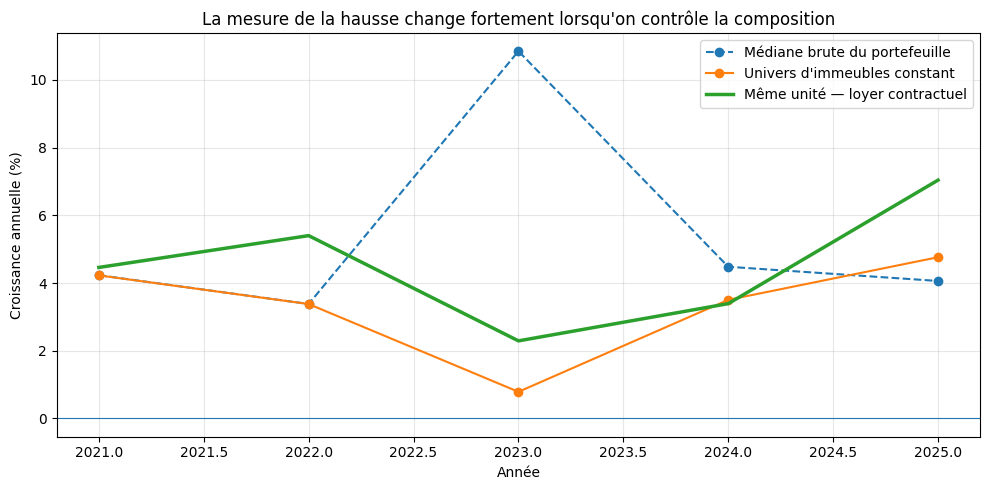

In [34]:
fig, ax = plt.subplots(figsize=(10, 5))

years = range(2021, 2026)

ax.plot(
    years,
    growth_comparison.loc[years, "naive_portfolio_pct"],
    marker="o",
    linestyle="--",
    label="Médiane brute du portefeuille"
)

ax.plot(
    years,
    growth_comparison.loc[years, "stable_buildings_pct"],
    marker="o",
    label="Univers d'immeubles constant"
)

ax.plot(
    years,
    growth_comparison.loc[years, "same_unit_contract_pct"],
    linewidth=2.5,
    label="Même unité — loyer contractuel"
)

ax.axhline(0, linewidth=0.8)

ax.set_title(
    "La mesure de la hausse change fortement lorsqu'on contrôle la composition"
)
ax.set_xlabel("Année")
ax.set_ylabel("Croissance annuelle (%)")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Les trois mesures comparées ici utilisent le loyer contractuel `sRent` afin que la comparaison de l'effet de composition soit homogène. Notre indicateur principal de prévision reste toutefois fondé sur `sRentEffective`, qui sera analysé séparément dans la suite.

### Conclusion sur l'effet de composition

L'analyse montre que la croissance du loyer médian du portefeuille ne constitue pas une mesure fiable de la hausse vécue par une unité donnée.

L'année 2023 constitue l'exemple le plus clair : la médiane globale augmente de 10,85 %, alors que la croissance à unité constante n'est que de 2,29 %. Lorsque l'univers est limité aux immeubles déjà présents avant 2023, la croissance médiane tombe même à 0,78 %.

Cette divergence s'explique par plusieurs changements simultanés : l'arrivée de nouveaux immeubles, la modification du poids relatif des bâtiments et l'évolution du mix de logements selon leur nombre de chambres et leur superficie.

Nous retenons donc la comparaison à unité constante comme base de la mesure de croissance utilisée pour la prévision. Les statistiques de portefeuille restent utiles pour comprendre le marché et la composition, mais elles ne sont pas interprétées comme une hausse de loyer à elles seules.

## 11. Validation de l'appariement à unité constante

La comparaison à unité constante repose sur l'appariement de chaque bail avec le bail précédent du même logement.

Le notebook de départ conserve les paires dont les dates de début sont espacées de plus de 0,5 an et de moins de 2,5 ans. Avant de conserver ces seuils, nous vérifions leur impact réel sur les données.

L'objectif est d'éviter qu'un seuil arbitraire devienne un « nombre magique ». Nous examinons donc la distribution des écarts temporels, les observations exclues et la sensibilité de la croissance mesurée à ces choix.

In [35]:
pair_candidates = (
    leases
    .sort_values(UNIT_KEY + ["sLeaseFrom"])
    .copy()
)

pair_candidates["prev_lease_from"] = (
    pair_candidates
    .groupby(UNIT_KEY)["sLeaseFrom"]
    .shift(1)
)

pair_candidates["prev_lease_to"] = (
    pair_candidates
    .groupby(UNIT_KEY)["sLeaseTo"]
    .shift(1)
)

pair_candidates["prev_term_months"] = (
    pair_candidates
    .groupby(UNIT_KEY)["sTermMonths"]
    .shift(1)
)

pair_candidates = pair_candidates.dropna(
    subset=["prev_lease_from"]
)

pair_candidates["gap_days"] = (
    pair_candidates["sLeaseFrom"]
    - pair_candidates["prev_lease_from"]
).dt.days

pair_candidates["gap_years"] = (
    pair_candidates["gap_days"] / 365.25
)

gap_audit = pd.DataFrame({
    "all_consecutive_pairs": [len(pair_candidates)],
    "gap_le_0_5_year": [
        (pair_candidates["gap_years"] <= 0.5).sum()
    ],
    "gap_between_0_5_and_2_5_years": [
        pair_candidates["gap_years"]
        .between(0.5, 2.5, inclusive="neither")
        .sum()
    ],
    "gap_ge_2_5_years": [
        (pair_candidates["gap_years"] >= 2.5).sum()
    ]
})

gap_audit

,all_consecutive_pairs,gap_le_0_5_year,gap_between_0_5_and_2_5_years,gap_ge_2_5_years
0,3241,62,3179,0


### 11.1 Nature des paires exclues par le seuil inférieur

Le nombre de paires exclues ne suffit pas à justifier le seuil. Nous examinons donc la durée du bail précédent pour comprendre la nature des observations situées à environ six mois.

In [36]:
short_gap_pairs = pair_candidates[
    pair_candidates["gap_years"] <= 0.5
]

short_gap_profile = (
    short_gap_pairs["prev_term_months"]
    .value_counts()
    .sort_index()
    .rename_axis("previous_term_months")
    .reset_index(name="n_pairs")
)

short_gap_profile

,previous_term_months,n_pairs
0,5.9,62


### Interprétation des seuils d'appariement

Parmi les 3 241 paires de baux consécutifs disponibles, 3 179 respectent le filtre initial de 0,5 à 2,5 ans.

Le seuil inférieur exclut 62 paires, soit environ 1,9 % des observations candidates. Ces 62 cas correspondent tous à un bail précédent d'environ 5,9 mois. Ils semblent donc représenter des baux courts réels plutôt que de simples doublons.

Le seuil supérieur de 2,5 ans n'exclut aucune paire dans l'extrait disponible.

Nous ne considérons donc pas le seuil de 0,5 an comme une règle de nettoyage évidente. Nous le conservons provisoirement comme filtre de comparabilité avec les baux de durée plus standard, puis nous vérifions que le résultat ne dépend pas matériellement de l'exclusion de ces baux courts.

### 11.2 Sensibilité à l'exclusion des baux courts

Les paires exclues par le seuil inférieur correspondent à de véritables baux d'environ six mois. Nous comparons donc les résultats obtenus avec le filtre initial du notebook et ceux obtenus en incluant également ces baux courts.

Nous effectuons ce contrôle à la fois sur le loyer contractuel (`sRent`) et sur le loyer effectif (`sRentEffective`).

L'objectif n'est pas de sélectionner la variante produisant le résultat souhaité, mais de vérifier si notre mesure de croissance est sensible à ce choix méthodologique.

In [37]:
sensitivity_rows = []

for metric_name, price_col in {
    "contractual": "sRent",
    "effective": "sRentEffective"
}.items():

    standard_pairs = same_unit_growth(
        leases,
        price_col=price_col,
        min_gap=0.5,
        max_gap=2.5
    )

    including_short_pairs = same_unit_growth(
        leases,
        price_col=price_col,
        min_gap=0.0,
        max_gap=2.5
    )

    for yr in range(2021, 2026):

        standard_median = (
            standard_pairs.loc[
                standard_pairs["year"] == yr,
                "growth_pct"
            ]
            .median()
        )

        including_short_median = (
            including_short_pairs.loc[
                including_short_pairs["year"] == yr,
                "growth_pct"
            ]
            .median()
        )

        sensitivity_rows.append({
            "metric": metric_name,
            "year": yr,
            "standard_filter_pct": standard_median,
            "include_short_leases_pct": including_short_median,
            "difference_pp": (
                including_short_median
                - standard_median
            ),
            "n_standard": (
                standard_pairs["year"] == yr
            ).sum(),
            "n_with_short": (
                including_short_pairs["year"] == yr
            ).sum()
        })

gap_sensitivity = pd.DataFrame(sensitivity_rows)

gap_sensitivity.round(3)

,metric,year,standard_filter_pct,include_short_leases_pct,difference_pp,n_standard,n_with_short
0,contractual,2021,4.457,4.493,0.036,355,361
1,contractual,2022,5.396,5.446,0.050,352,359
2,contractual,2023,2.288,2.325,0.037,416,424
3,contractual,2024,3.389,3.427,0.038,698,706
4,contractual,2025,7.045,7.113,0.069,780,795
5,effective,2021,3.543,3.547,0.004,355,361
6,effective,2022,4.586,4.609,0.022,352,359
7,effective,2023,2.019,2.098,0.078,416,424
8,effective,2024,1.772,1.865,0.094,698,706
9,effective,2025,3.575,3.639,0.064,780,795


> **Note sur le filtre du notebook de départ**
>
> Le notebook de départ suggère que les écarts inférieurs à 0,5 an peuvent
> correspondre à un même bail enregistré deux fois. Nous ne reprenons pas
> cette hypothèse sans vérification.
>
> Notre audit détaillé en section 11 montre que les 62 paires concernées
> correspondent principalement à de véritables baux courts d'environ
> 5,9 mois. Nous conservons néanmoins le seuil de 0,5 an afin de travailler
> sur un ensemble de baux plus homogène, après avoir vérifié par analyse de
> sensibilité que leur réintégration modifie les estimations historiques de
> moins de 0,1 point de pourcentage.
>
> Nous distinguons donc explicitement l'hypothèse du notebook
> de départ de la conclusion obtenue après audit de nos données.

### Interprétation de l'analyse de sensibilité

L'inclusion des baux courts modifie très peu les estimations de croissance.

Pour le loyer contractuel, la différence entre les deux variantes reste comprise entre 0,036 et 0,069 point de pourcentage selon l'année. Pour le loyer effectif, l'écart maximal observé est de 0,094 point de pourcentage.

L'exclusion des 62 baux courts n'a donc pas d'effet matériel sur les médianes historiques. Notre mesure est robuste à ce choix méthodologique.

Nous conservons le filtre initial de 0,5 à 2,5 ans afin de maintenir un ensemble de baux plus homogène et comparable, tout en précisant que les observations exclues semblent correspondre à de véritables baux courts et non à des doublons.

Le seuil supérieur de 2,5 ans n'exclut aucune observation dans l'extrait fourni ; il agit donc ici comme une protection méthodologique plutôt que comme un filtre ayant un impact sur les résultats.

### 11.3 Distribution des croissances à unité constante

La médiane est robuste aux valeurs extrêmes, mais nous devons néanmoins examiner la distribution complète des variations observées.

Une croissance inhabituellement élevée ou négative n'est pas nécessairement une erreur : elle peut correspondre à une relocation, à un repositionnement de prix ou à une évolution importante des concessions.

Nous examinons donc les principaux quantiles, la moyenne, la médiane et les valeurs extrêmes avant de décider si certaines observations nécessitent une investigation particulière. Aucun seuil d'exclusion supplémentaire n'est appliqué à ce stade.

In [38]:
def growth_distribution(df, metric_name):
    result = (
        df[df["year"].between(2021, 2025)]
        .groupby("year")["growth_pct"]
        .agg(
            n="size",
            mean="mean",
            median="median",
            min="min",
            p01=lambda x: x.quantile(0.01),
            p05=lambda x: x.quantile(0.05),
            p25=lambda x: x.quantile(0.25),
            p75=lambda x: x.quantile(0.75),
            p95=lambda x: x.quantile(0.95),
            p99=lambda x: x.quantile(0.99),
            max="max"
        )
        .reset_index()
    )

    result.insert(0, "metric", metric_name)
    return result


contractual_distribution = growth_distribution(
    pairs,
    "contractual"
)

effective_distribution = growth_distribution(
    eff,
    "effective"
)

growth_distribution_summary = pd.concat(
    [
        contractual_distribution,
        effective_distribution
    ],
    ignore_index=True
)

growth_distribution_summary.round(2)

,metric,year,n,mean,median,min,p01,p05,p25,p75,p95,p99,max
0,contractual,2021,355,4.38,4.46,-3.09,-1.15,0.69,3.32,5.67,7.74,9.73,13.90
1,contractual,2022,352,5.27,5.40,-3.44,-0.86,1.42,4.02,6.57,8.69,10.45,17.06
2,contractual,2023,416,2.09,2.29,-6.25,-3.55,-1.89,1.01,3.38,5.25,6.94,8.99
3,contractual,2024,698,3.73,3.39,-1.56,-0.51,0.68,2.19,4.81,8.53,9.88,14.90
4,contractual,2025,780,7.56,7.04,1.23,3.06,4.05,5.83,8.81,12.75,16.48,25.87
5,effective,2021,355,3.75,3.54,-6.89,-4.39,-2.34,0.69,5.96,10.80,13.36,15.29
6,effective,2022,352,4.72,4.59,-5.76,-4.38,-2.34,1.04,7.74,12.48,14.49,15.09
7,effective,2023,416,2.18,2.02,-12.27,-9.57,-5.67,-0.72,5.32,10.23,12.17,20.30
8,effective,2024,698,1.95,1.77,-9.33,-7.85,-6.40,-2.25,4.82,12.90,15.27,17.65
9,effective,2025,780,3.83,3.58,-9.79,-8.40,-5.83,1.06,6.32,16.11,20.70,31.72


### Interprétation de la distribution des croissances

Les distributions contractuelle et effective présentent des comportements sensiblement différents.

La croissance contractuelle reste relativement concentrée autour de sa médiane. En 2025, par exemple, toutes les paires observées présentent une croissance contractuelle positive, avec un minimum de 1,23 % et une médiane de 7,04 %.

La croissance du loyer effectif est beaucoup plus dispersée. En 2025, elle varie de -9,79 % à 31,72 %, alors que sa médiane n'est que de 3,58 %. Cette dispersion est cohérente avec l'effet des concessions : une augmentation du loyer inscrit au bail peut être partiellement ou totalement compensée par les avantages accordés au locataire.

Les valeurs extrêmes ne sont pas supprimées à ce stade. Elles peuvent correspondre à de véritables situations économiques, notamment lors d'une relocation ou d'une modification importante des concessions. Nous privilégions plutôt la médiane, naturellement moins sensible à ces observations extrêmes.

### 11.4 Robustesse de la médiane

Notre indicateur principal utilise la médiane plutôt que la moyenne.

La moyenne accorde davantage de poids aux variations extrêmes, tandis que la médiane décrit la variation centrale d'une unité typique. Nous comparons les deux afin de vérifier si quelques observations importantes modifient fortement le signal agrégé.

In [39]:
central_tendency = (
    growth_distribution_summary[
        ["metric", "year", "n", "mean", "median"]
    ]
    .copy()
)

central_tendency["mean_minus_median_pp"] = (
    central_tendency["mean"]
    - central_tendency["median"]
)

central_tendency.round(2)

,metric,year,n,mean,median,mean_minus_median_pp
0,contractual,2021,355,4.38,4.46,-0.07
1,contractual,2022,352,5.27,5.40,-0.12
2,contractual,2023,416,2.09,2.29,-0.20
3,contractual,2024,698,3.73,3.39,0.34
4,contractual,2025,780,7.56,7.04,0.51
5,effective,2021,355,3.75,3.54,0.21
6,effective,2022,352,4.72,4.59,0.13
7,effective,2023,416,2.18,2.02,0.16
8,effective,2024,698,1.95,1.77,0.18
9,effective,2025,780,3.83,3.58,0.26


### Interprétation de la robustesse de la médiane

La moyenne et la médiane restent relativement proches sur l'ensemble de la période.

Pour le loyer contractuel, l'écart maximal entre moyenne et médiane est de 0,51 point de pourcentage. Pour le loyer effectif, il ne dépasse pas 0,26 point.

Les valeurs extrêmes observées ne semblent donc pas dominer le signal central. Cette stabilité renforce notre choix de la médiane comme statistique principale, tout en nous permettant de conserver les observations atypiques plutôt que d'introduire un seuil d'exclusion arbitraire.

### 11.5 Part des croissances négatives

Une croissance négative n'a pas la même signification selon que nous observons le loyer contractuel ou le loyer effectif.

Une baisse contractuelle signifie que le nouveau bail comporte directement un loyer inférieur au précédent. Une baisse effective peut également apparaître lorsque le loyer contractuel augmente mais que les concessions deviennent suffisamment importantes pour réduire la valeur économique du nouveau bail.

Nous mesurons donc la proportion de paires présentant une croissance négative pour les deux définitions.

In [40]:
negative_growth_rows = []

for metric_name, df in {
    "contractual": pairs,
    "effective": eff
}.items():

    yearly_negative_share = (
        df[df["year"].between(2021, 2025)]
        .groupby("year")["growth_pct"]
        .agg(
            n_pairs="size",
            pct_negative=lambda x: (x < 0).mean() * 100,
            pct_positive=lambda x: (x > 0).mean() * 100
        )
        .reset_index()
    )

    yearly_negative_share.insert(
        0,
        "metric",
        metric_name
    )

    negative_growth_rows.append(
        yearly_negative_share
    )

negative_growth_share = pd.concat(
    negative_growth_rows,
    ignore_index=True
)

negative_growth_share.round(2)

,metric,year,n_pairs,pct_negative,pct_positive
0,contractual,2021,355,3.66,96.06
1,contractual,2022,352,1.42,97.73
2,contractual,2023,416,12.98,85.58
3,contractual,2024,698,1.58,97.56
4,contractual,2025,780,0.00,100.00
5,effective,2021,355,20.56,79.44
6,effective,2022,352,18.47,81.25
7,effective,2023,416,28.12,71.63
8,effective,2024,698,34.24,65.76
9,effective,2025,780,20.77,79.23


### Interprétation des croissances négatives

La différence entre croissance contractuelle et croissance effective est particulièrement nette.

Les baisses de loyer contractuel restent relativement rares sur l'ensemble de la période. En 2025, aucune des 780 paires observées ne présente même de baisse contractuelle : 100 % des nouveaux baux ont un loyer contractuel supérieur au bail précédent.

La situation est très différente après prise en compte des concessions. Entre 18 % et 34 % des paires présentent selon l'année une croissance effective négative. En 2024, par exemple, 34,24 % des logements comparables ont un loyer effectif inférieur à celui de leur bail précédent, alors que seulement 1,58 % présentent une baisse contractuelle.

Une augmentation inscrite au bail ne se traduit donc pas nécessairement par une augmentation économique équivalente pour le propriétaire. Les concessions peuvent absorber une partie, voire la totalité, de la hausse contractuelle.

Cette divergence confirme notre choix d'utiliser `sRentEffective` comme indicateur principal de la croissance réalisée, tout en conservant `sRent` pour comprendre la stratégie de tarification contractuelle.

## 12. Renouvellements et relocations

Un renouvellement et une relocation ne représentent pas la même situation économique.

Lors d'un renouvellement (`sRenewal = 1`), le locataire existant demeure dans l'unité. Lors d'une relocation (`sRenewal = 0`), un nouveau bail est conclu après le départ du locataire précédent.

Ces deux situations peuvent présenter des possibilités de repositionnement différentes et sont également influencées par des cadres réglementaires distincts.

Nous comparons donc séparément la croissance contractuelle et la croissance effective des renouvellements et des relocations avant toute agrégation pour la prévision 2026.

In [41]:
renewal_analysis_rows = []

for metric_name, df in {
    "contractual": pairs,
    "effective": eff
}.items():

    result = (
        df[df["year"].between(2022, 2025)]
        .groupby(["year", "sRenewal"])
        ["growth_pct"]
        .agg(
            n_pairs="size",
            mean_pct="mean",
            median_pct="median"
        )
        .reset_index()
    )

    result["lease_type"] = result["sRenewal"].map({
        0: "relocation",
        1: "renewal"
    })

    result.insert(
        0,
        "metric",
        metric_name
    )

    renewal_analysis_rows.append(result)

renewal_analysis = pd.concat(
    renewal_analysis_rows,
    ignore_index=True
)

renewal_analysis[
    [
        "metric",
        "year",
        "lease_type",
        "n_pairs",
        "mean_pct",
        "median_pct"
    ]
].round(2)

,metric,year,lease_type,n_pairs,mean_pct,median_pct
0,contractual,2022,relocation,126,4.28,4.22
1,contractual,2022,renewal,226,5.83,5.69
2,contractual,2023,relocation,177,1.47,1.85
3,contractual,2023,renewal,239,2.55,2.58
4,contractual,2024,relocation,276,4.97,4.85
5,contractual,2024,renewal,422,2.91,2.94
6,contractual,2025,relocation,307,9.19,8.98
7,contractual,2025,renewal,473,6.50,6.41
8,effective,2022,relocation,126,3.99,3.40
9,effective,2022,renewal,226,5.12,4.92


### Interprétation des renouvellements et relocations

Les renouvellements et les relocations ne suivent pas une relation stable sur toute la période.

En 2022 et 2023, la croissance médiane est plus élevée lors des renouvellements que lors des relocations, aussi bien en loyer contractuel qu'en loyer effectif.

La relation s'inverse à partir de 2024. En 2025, la croissance contractuelle médiane atteint 8,98 % lors des relocations contre 6,41 % lors des renouvellements. Après prise en compte des concessions, ces valeurs tombent respectivement à 5,74 % et 2,91 %.

Cette évolution montre qu'il serait incorrect d'appliquer une prime fixe de relocation à toutes les années. Le différentiel entre renouvellement et relocation dépend du contexte de marché et de la politique de concessions.

Nous modéliserons donc ces deux situations séparément avant leur agrégation dans la prévision 2026.

### 12.1 Écart entre croissance contractuelle et croissance effective

Pour quantifier l'impact économique des concessions, nous calculons l'écart entre la croissance contractuelle médiane et la croissance effective médiane pour chaque type de bail.

Nous appelons cet écart `concession_drag_pp`. Il est exprimé en points de pourcentage et ne représente pas une concession individuelle : il mesure la différence entre les deux indicateurs de croissance agrégés.

Une augmentation de cet écart signifie que la croissance affichée dans les contrats se traduit de moins en moins directement en croissance effective.

In [42]:
contractual_by_type = (
    pairs[pairs["year"].between(2022, 2025)]
    .groupby(["year", "sRenewal"])["growth_pct"]
    .median()
    .rename("contractual_median_pct")
)

effective_by_type = (
    eff[eff["year"].between(2022, 2025)]
    .groupby(["year", "sRenewal"])["growth_pct"]
    .median()
    .rename("effective_median_pct")
)

concession_drag = pd.concat(
    [
        contractual_by_type,
        effective_by_type
    ],
    axis=1
).reset_index()

concession_drag["lease_type"] = (
    concession_drag["sRenewal"]
    .map({
        0: "relocation",
        1: "renewal"
    })
)

concession_drag["concession_drag_pp"] = (
    concession_drag["contractual_median_pct"]
    - concession_drag["effective_median_pct"]
)

concession_drag[
    [
        "year",
        "lease_type",
        "contractual_median_pct",
        "effective_median_pct",
        "concession_drag_pp"
    ]
].round(2)

,year,lease_type,contractual_median_pct,effective_median_pct,concession_drag_pp
0,2022,relocation,4.22,3.40,0.81
1,2022,renewal,5.69,4.92,0.76
2,2023,relocation,1.85,1.68,0.17
3,2023,renewal,2.58,2.21,0.36
4,2024,relocation,4.85,2.75,2.11
5,2024,renewal,2.94,1.38,1.56
6,2025,relocation,8.98,5.74,3.24
7,2025,renewal,6.41,2.91,3.50


### Interprétation de l'écart contractuel-effectif

L'écart entre croissance contractuelle et croissance effective augmente fortement à partir de 2024.

En 2022 et 2023, les deux mesures restent relativement proches. En 2025, la croissance médiane contractuelle atteint 8,98 % lors des relocations et 6,41 % lors des renouvellements, tandis que la croissance effective correspondante n'est plus que de 5,74 % et 2,91 %.

L'écart atteint ainsi 3,24 points de pourcentage pour les relocations et 3,50 points pour les renouvellements en 2025.

Cette évolution suggère que les concessions jouent désormais un rôle beaucoup plus important dans la traduction d'une hausse contractuelle en croissance économique réellement obtenue. La prévision 2026 devra donc éviter d'extrapoler directement les seules hausses contractuelles.

## 13. Segmentation géographique et réglementaire

Cinq des six immeubles de l'extrait sont situés au Québec, tandis que The Met est situé en Ontario.

Cette distinction est importante pour deux raisons. Premièrement, Montréal/Laval/Pointe-Claire et Ottawa ne représentent pas nécessairement les mêmes conditions de marché. Deuxièmement, les augmentations de loyers ne sont pas encadrées de la même manière au Québec et en Ontario.

Avant d'intégrer les règles réglementaires ou des données de marché externes, nous examinons donc si les comportements historiques diffèrent déjà entre les deux provinces.

Nous conservons également la distinction entre renouvellements et relocations afin de ne pas confondre l'effet de la province avec celui du type de bail.

In [43]:
province_analysis_rows = []

for metric_name, df in {
    "contractual": pairs,
    "effective": eff
}.items():

    result = (
        df[df["year"].between(2022, 2025)]
        .groupby(
            ["year", "sState", "sRenewal"]
        )["growth_pct"]
        .agg(
            n_pairs="size",
            mean_pct="mean",
            median_pct="median"
        )
        .reset_index()
    )

    result["lease_type"] = (
        result["sRenewal"]
        .map({
            0: "relocation",
            1: "renewal"
        })
    )

    result.insert(
        0,
        "metric",
        metric_name
    )

    province_analysis_rows.append(result)


province_analysis = pd.concat(
    province_analysis_rows,
    ignore_index=True
)

province_analysis[
    [
        "metric",
        "year",
        "sState",
        "lease_type",
        "n_pairs",
        "mean_pct",
        "median_pct"
    ]
].round(2)

,metric,year,sState,lease_type,n_pairs,mean_pct,median_pct
0,contractual,2022,Quebec,relocation,126,4.28,4.22
1,contractual,2022,Quebec,renewal,226,5.83,5.69
2,contractual,2023,Quebec,relocation,177,1.47,1.85
3,contractual,2023,Quebec,renewal,239,2.55,2.58
4,contractual,2024,Ontario,relocation,41,5.08,4.94
5,contractual,2024,Ontario,renewal,67,2.90,2.97
6,contractual,2024,Quebec,relocation,235,4.96,4.84
7,contractual,2024,Quebec,renewal,355,2.91,2.94
8,contractual,2025,Ontario,relocation,54,8.92,8.96
9,contractual,2025,Ontario,renewal,63,6.33,6.25


### Interprétation de la segmentation provinciale

Les comportements contractuels observés au Québec et en Ontario sont étonnamment proches sur les années où les deux provinces disposent d'un historique à unité constante.

En 2024, la croissance contractuelle médiane des relocations est de 4,94 % en Ontario contre 4,84 % au Québec, tandis que celle des renouvellements est de 2,97 % contre 2,94 %. En 2025, les écarts restent également faibles.

Après concessions, certaines différences apparaissent davantage, mais le type de bail demeure un facteur de segmentation plus marqué que la province dans l'historique disponible.

Ces résultats doivent cependant être interprétés avec prudence : The Met représente un nombre de paires beaucoup plus faible que les immeubles québécois. Nous ne considérons donc pas les médianes ontariennes comme aussi stables statistiquement que celles du Québec.

La province reste néanmoins indispensable dans la prévision 2026, non seulement pour les conditions de marché propres à Ottawa et au Québec, mais aussi parce que les cadres réglementaires applicables aux renouvellements sont différents.

### 13.1 Cadres réglementaires applicables en 2026

Les données historiques ne suffisent pas à elles seules pour prévoir les renouvellements de 2026. Nous intégrons donc le contexte réglementaire propre à chaque province.

#### Québec

Le Tribunal administratif du logement a publié le 19 janvier 2026 un pourcentage de base de 3,1 % dans la nouvelle méthode de fixation applicable aux avis visés.

Cette information est utile pour interpréter a posteriori le contexte réglementaire de 2026, mais elle n'était pas encore disponible à notre date d'origine de prévision du 31 décembre 2025.

Le 3,1 % est donc documenté comme contexte réglementaire **postérieur au cutoff**, mais il n'entre pas dans la prévision principale. Cette règle permet de conserver une méthode comparable à celle utilisée dans les backtests.

#### Ontario — The Met

Le guideline ontarien pour 2026 est de 2,1 % pour les logements qui y sont assujettis.

Cependant, le cadre ontarien prévoit deux distinctions essentielles pour notre analyse :

1. le guideline ne s'applique pas lors d'une relocation, lorsqu'un nouveau locataire prend possession du logement ;
2. les logements situés dans des immeubles occupés pour la première fois à des fins résidentielles après le 15 novembre 2018 peuvent être exemptés du contrôle des loyers.

Nous ne plafonnons donc pas automatiquement les relocations de The Met à 2,1 %. Pour les renouvellements, l'application exacte du guideline dépend du statut réglementaire de l'immeuble et doit être vérifiée avant d'être utilisée comme contrainte de modélisation.

#### 13.1.1 Statut réglementaire de The Met

La règle ontarienne dépend de la date de première occupation résidentielle,
et non simplement de l'année apparente de construction.

Les données du défi ne permettent pas de démontrer juridiquement cette date.
Nous ne classons donc pas arbitrairement The Met comme assujetti ou exempt.

Nous retenons deux scénarios réglementaires :

- **The Met exempt** : le signal économique interne reste applicable ;
- **The Met assujetti** : le guideline 2026 de 2,1 % constitue la référence
  réglementaire pour un locataire en place, sous réserve notamment des
  mécanismes d'augmentation au-dessus du guideline.

Le guideline ne s'applique pas à une relocation, où le propriétaire et le
nouveau locataire conviennent du nouveau loyer.

Une analyse de sensibilité réglementaire de ces hypothèses est présentée
avec la segmentation de la prévision 2026.

### 13.2 Paramètres réglementaires documentés

Les paramètres réglementaires externes sont stockés séparément de la logique de prévision afin de distinguer clairement les données internes des hypothèses et informations publiques.

Ces valeurs ne constituent pas à elles seules une prévision de croissance.

In [44]:
regulatory_context_2026 = pd.DataFrame([
    {
        "province": "Quebec",
        "parameter": "TAL 2026 base percentage",
        "value_pct": 3.1,
        "publication_date": "2026-01-19",
        "available_at_forecast_cutoff": False,
        "model_role": "post-cutoff context only"
    },
    {
        "province": "Ontario",
        "parameter": "2026 rent increase guideline",
        "value_pct": 2.1,
        "publication_date": "2025-06-30",
        "available_at_forecast_cutoff": True,
        "model_role": "conditional regulatory input"
    }
])

regulatory_context_2026["publication_date"] = pd.to_datetime(
    regulatory_context_2026["publication_date"]
)

regulatory_context_2026

,province,parameter,value_pct,publication_date,available_at_forecast_cutoff,model_role
0,Quebec,TAL 2026 base percentage,3.1,2026-01-19,False,post-cutoff context only
1,Ontario,2026 rent increase guideline,2.1,2025-06-30,True,conditional regulatory input


### Interprétation

Le paramètre TAL 2026 est documenté dans le notebook, mais il n'entre pas dans la prévision principale puisque sa publication est postérieure au 31 décembre 2025.

Le guideline ontarien 2026 était en revanche déjà public avant cette date. Il peut donc être considéré comme une information disponible pour la prévision, sous réserve que le logement soit effectivement assujetti au contrôle des loyers.

Cette distinction permet de conserver une prévision 2026 comparable méthodologiquement aux backtests historiques.

## 14. Données externes et contrôle de disponibilité

Les données publiques servent à replacer la tendance interne d'Équinoxe dans son contexte de marché et de réglementation.

Cependant, une donnée externe ne peut être utilisée dans une prévision historique que si elle était réellement publiée à la date où cette prévision aurait été produite.

Nous fixons donc une date d'origine de prévision au 31 décembre de l'année précédant l'année cible. Cette règle sera appliquée aussi bien à la prévision 2026 qu'aux backtests 2023, 2024 et 2025.

Les sources principales sont celles recommandées dans la documentation du défi :

- SCHL : marché locatif de Montréal et Ottawa ;
- Statistique Canada : IPC, composante loyers ;
- Tribunal administratif du logement : contexte réglementaire québécois ;
- Gouvernement de l'Ontario : ligne directrice d'augmentation des loyers.

Chaque source sera enregistrée avec sa date de publication afin d'éviter toute fuite d'information.

In [45]:
FORECAST_CUTOFF = pd.Timestamp("2025-12-31")

def source_available(publication_date, cutoff=FORECAST_CUTOFF):
    publication_date = pd.Timestamp(publication_date)
    return publication_date <= cutoff

### 14.1 Disponibilité temporelle des données externes

Avant d'utiliser une donnée publique dans une prévision ou un backtest, nous vérifions qu'elle était effectivement disponible à la date de prévision.

Le tableau suivant ne constitue pas la bibliographie du projet. Il sert uniquement à contrôler la disponibilité temporelle des principales données externes et à prévenir toute fuite d'information.

Les références complètes, liens et dates de consultation sont regroupés dans la section Références à la fin du notebook.

In [46]:
external_source_registry = pd.DataFrame([
    {
        "source": "CMHC Rental Market Report 2022",
        "observed_year": 2022,
        "publication_date": "2023-01-26",
        "category": "rental_market"
    },
    {
        "source": "CMHC Rental Market Report 2023",
        "observed_year": 2023,
        "publication_date": "2024-01-31",
        "category": "rental_market"
    },
    {
        "source": "CMHC Rental Market Report 2024",
        "observed_year": 2024,
        "publication_date": "2024-12-17",
        "category": "rental_market"
    },
    {
        "source": "CMHC Rental Market Report 2025",
        "observed_year": 2025,
        "publication_date": "2025-12-11",
        "category": "rental_market"
    },
    {
        "source": "TAL 2026 parameters",
        "observed_year": 2026,
        "publication_date": "2026-01-19",
        "category": "regulation"
    },
    {
        "source": "Ontario 2026 rent guideline",
        "observed_year": 2026,
        "publication_date": "2025-06-30",
        "category": "regulation"
    }
])

external_source_registry["publication_date"] = pd.to_datetime(
    external_source_registry["publication_date"]
)

external_source_registry["available_for_2026_forecast"] = (
    external_source_registry["publication_date"]
    <= FORECAST_CUTOFF
)

external_source_registry

,source,observed_year,publication_date,category,available_for_2026_forecast
0,CMHC Rental Market Report 2022,2022,2023-01-26,rental_market,True
1,CMHC Rental Market Report 2023,2023,2024-01-31,rental_market,True
2,CMHC Rental Market Report 2024,2024,2024-12-17,rental_market,True
3,CMHC Rental Market Report 2025,2025,2025-12-11,rental_market,True
4,TAL 2026 parameters,2026,2026-01-19,regulation,False
5,Ontario 2026 rent guideline,2026,2025-06-30,regulation,True


### 14.2 Marché locatif externe — SCHL

La SCHL constitue notre principale source externe pour relier les observations internes d'Équinoxe aux conditions du marché locatif.

Nous utilisons principalement trois types d'information :

1. le taux d'inoccupation comme indicateur de tension du marché ;
2. le loyer des logements avec changement de locataire comme signal de prix de relocation ;
3. la différence entre logements avec et sans changement de locataire pour confronter notre séparation `sRenewal`.

Ces données décrivent les RMR de Montréal et d'Ottawa. Elles ne représentent donc pas directement les immeubles Équinoxe et ne sont jamais interprétées comme un taux d'occupation propre au portefeuille.

In [47]:
cmhc_2025_market = pd.DataFrame([
    {
        "market": "Montreal",
        "year": 2025,
        "vacancy_rate_pct": 2.9,
        "turnover_2br_rent": 1644
    },
    {
        "market": "Ottawa",
        "year": 2025,
        "vacancy_rate_pct": 3.0,
        "turnover_2br_rent": 2155
    }
])

cmhc_2025_market

,market,year,vacancy_rate_pct,turnover_2br_rent
0,Montreal,2025,2.9,1644
1,Ottawa,2025,3.0,2155


### 14.3 Évolution du loyer de relocation dans le marché externe

Le loyer moyen des logements de deux chambres ayant changé de locataire fournit un indicateur de la pression exercée sur les nouvelles locations.

Nous utilisons cette série comme signal de marché et non comme prédiction directe du loyer Équinoxe : les immeubles Équinoxe sont des actifs particuliers, avec un positionnement et un niveau de prix différents de la moyenne métropolitaine.

In [48]:
cmhc_turnover_rent = pd.DataFrame({
    "year": [2022, 2023, 2024, 2025],
    "Montreal": [1235, 1310, 1407, 1644],
    "Ottawa": [1829, 1903, 2118, 2155]
})

cmhc_turnover_rent["Montreal_turnover_avg_yoy_pct"] = (
    cmhc_turnover_rent["Montreal"]
    .pct_change()
    * 100
)

cmhc_turnover_rent["Ottawa_turnover_avg_yoy_pct"] = (
    cmhc_turnover_rent["Ottawa"]
    .pct_change()
    * 100
)

cmhc_turnover_rent.round(2)

,year,Montreal,Ottawa,Montreal_turnover_avg_yoy_pct,Ottawa_turnover_avg_yoy_pct
0,2022,1235,1829,NaN,NaN
1,2023,1310,1903,6.07,4.05
2,2024,1407,2118,7.40,11.30
3,2025,1644,2155,16.84,1.75


### Interprétation

Cette variation mesure l'évolution du **loyer moyen des unités de deux chambres ayant changé de locataire** dans chaque RMR. Elle ne constitue pas une croissance à unité constante comparable directement à notre indicateur interne.

Nous l'utilisons comme signal de direction et d'intensité du marché des nouvelles locations, et non comme taux de croissance à appliquer directement aux logements Équinoxe.

En 2025, le loyer moyen turnover augmente fortement à Montréal (+16,84 %) mais beaucoup plus faiblement à Ottawa (+1,75 %), ce qui suggère des conditions de marché différentes entre les deux régions.

### 14.4 IPC des loyers — Statistique Canada

La SCHL décrit principalement le marché locatif à partir de son enquête sur les logements, tandis que l'Indice des prix à la consommation de Statistique Canada fournit un autre signal : l'évolution des prix des loyers observés dans l'économie.

Nous utilisons la composante loyers du tableau 18-10-0004-01 pour le Québec et l'Ontario.

Pour la prévision 2026, nous retenons le taux sur 12 mois de septembre 2025. Cette observation a été publiée le 21 octobre 2025 et était donc disponible avant notre date d'origine de prévision du 31 décembre 2025.

Cet indicateur n'est pas directement comparable à notre croissance à unité constante : il représente une tendance de marché provinciale plus large. Nous l'utilisons donc comme signal externe, et non comme taux à appliquer directement aux loyers Équinoxe.

In [49]:
statcan_rent_cpi_2025 = pd.DataFrame([
    {
        "province": "Quebec",
        "reference_month": "2025-09",
        "rent_yoy_pct": 9.6,
        "publication_date": "2025-10-21"
    },
    {
        "province": "Ontario",
        "reference_month": "2025-09",
        "rent_yoy_pct": 3.5,
        "publication_date": "2025-10-21"
    }
])

statcan_rent_cpi_2025["reference_month"] = pd.to_datetime(
    statcan_rent_cpi_2025["reference_month"]
)

statcan_rent_cpi_2025["publication_date"] = pd.to_datetime(
    statcan_rent_cpi_2025["publication_date"]
)

statcan_rent_cpi_2025["available_at_forecast_cutoff"] = (
    statcan_rent_cpi_2025["publication_date"]
    <= FORECAST_CUTOFF
)

statcan_rent_cpi_2025

,province,reference_month,rent_yoy_pct,publication_date,available_at_forecast_cutoff
0,Quebec,2025-09-01,9.6,2025-10-21,True
1,Ontario,2025-09-01,3.5,2025-10-21,True


### Interprétation

Le signal externe diffère fortement entre les deux provinces : en septembre 2025, la composante loyers de l'IPC progresse de 9,6 % sur un an au Québec contre 3,5 % en Ontario.

Ces taux ne constituent pas des prévisions directes pour Équinoxe. Ils couvrent un marché beaucoup plus large et ne contrôlent pas l'effet de composition de la même manière que notre approche à unité constante.

Ils permettent néanmoins de qualifier l'environnement dans lequel les nouveaux baux sont négociés : le signal de prix provincial est nettement plus dynamique au Québec qu'en Ontario à l'approche de 2026.

### 14.5 Intégration de Statistique Canada 

La fonction de contrôle temporel doit couvrir l'ensemble des données externes utilisées, et pas uniquement les rapports SCHL et les paramètres réglementaires.

Nous ajoutons donc la publication de Statistique Canada au registre de disponibilité. Cette intégration sert à documenter ce qui était connu à la date de prévision ; elle ne signifie pas que l'IPC sera automatiquement utilisé comme variable de prévision.



In [50]:
statcan_registry_rows = pd.DataFrame([
    {
        "source": "Statistics Canada rent CPI - September 2025",
        "observed_year": 2025,
        "publication_date": pd.Timestamp("2025-10-21"),
        "category": "rent_cpi"
    }
])

external_source_registry = pd.concat(
    [
        external_source_registry,
        statcan_registry_rows
    ],
    ignore_index=True
)

external_source_registry = (
    external_source_registry
    .drop_duplicates(
        subset=["source", "publication_date"]
    )
    .sort_values("publication_date")
    .reset_index(drop=True)
)

external_source_registry["available_for_2026_forecast"] = (
    external_source_registry["publication_date"]
    <= FORECAST_CUTOFF
)

external_source_registry


,source,observed_year,publication_date,category,available_for_2026_forecast
0,CMHC Rental Market Report 2022,2022,2023-01-26,rental_market,True
1,CMHC Rental Market Report 2023,2023,2024-01-31,rental_market,True
2,CMHC Rental Market Report 2024,2024,2024-12-17,rental_market,True
3,Ontario 2026 rent guideline,2026,2025-06-30,regulation,True
4,Statistics Canada rent CPI - September 2025,2025,2025-10-21,rent_cpi,True
5,CMHC Rental Market Report 2025,2025,2025-12-11,rental_market,True
6,TAL 2026 parameters,2026,2026-01-19,regulation,False


### 14.6 Filtrage des sources disponibles 

Afin d'utiliser exactement la même logique dans la prévision 2026 et dans les backtests, nous centralisons le contrôle de disponibilité temporelle.

La fonction suivante retourne uniquement les sources qui avaient été publiées à la date de prévision considérée.

Elle ne sélectionne pas encore les variables finales du modèle : elle constitue une protection contre l'utilisation accidentelle d'informations futures.


In [51]:
def available_sources_as_of(cutoff):
    cutoff = pd.Timestamp(cutoff)

    available = external_source_registry[
        external_source_registry["publication_date"] <= cutoff
    ].copy()

    return (
        available
        .sort_values("publication_date")
        .reset_index(drop=True)
    )


In [52]:
for target_year in [2023, 2024, 2025, 2026]:

    cutoff = pd.Timestamp(
        f"{target_year - 1}-12-31"
    )

    available = available_sources_as_of(cutoff)

    print(
        f"\nPrévision {target_year} "
        f"(cutoff {cutoff.date()})"
    )

    print(
        available[
            [
                "source",
                "observed_year",
                "publication_date"
            ]
        ].to_string(index=False)
    )



Prévision 2023 (cutoff 2022-12-31)
Empty DataFrame
Columns: [source, observed_year, publication_date]
Index: []

Prévision 2024 (cutoff 2023-12-31)
                        source  observed_year publication_date
CMHC Rental Market Report 2022           2022       2023-01-26

Prévision 2025 (cutoff 2024-12-31)
                        source  observed_year publication_date
CMHC Rental Market Report 2022           2022       2023-01-26
CMHC Rental Market Report 2023           2023       2024-01-31
CMHC Rental Market Report 2024           2024       2024-12-17

Prévision 2026 (cutoff 2025-12-31)
                                     source  observed_year publication_date
             CMHC Rental Market Report 2022           2022       2023-01-26
             CMHC Rental Market Report 2023           2023       2024-01-31
             CMHC Rental Market Report 2024           2024       2024-12-17
                Ontario 2026 rent guideline           2026       2025-06-30
Statistics Canada ren

### Interprétation du contrôle de disponibilité

Le test confirme que les données externes utilisables changent selon la
date de prévision.

Pour le backtest 2023, aucun des rapports annuels SCHL enregistrés dans
notre registre n'était encore publié au 31 décembre 2022. Pour 2024,
seul le rapport 2022 était disponible. En revanche, le rapport SCHL 2024
avait déjà été publié avant le cutoff du backtest 2025.

La prévision 2026 peut quant à elle utiliser le rapport SCHL 2025,
l'observation IPC de septembre 2025 et le guideline ontarien 2026,
puisqu'ils étaient tous publiés avant le 31 décembre 2025.

Cette vérification empêche d'améliorer artificiellement les backtests en
leur donnant accès à des informations qui n'existaient pas encore au moment
où la prévision aurait dû être produite.

## 15. Construction de la cible historique

Avant de choisir une méthode de prévision, nous construisons explicitement la variable que les backtests devront prédire.

Notre cible est la croissance médiane annualisée du loyer effectif à unité constante. Elle est calculée à partir de `sRentEffective`, en appliquant les mêmes règles d'appariement validées précédemment.

Cette table constitue la vérité historique contre laquelle les différentes méthodes de prévision seront évaluées.

In [53]:
effective_pairs = same_unit_growth(
    leases,
    price_col="sRentEffective",
    min_gap=0.5,
    max_gap=2.5
)

historical_target = (
    effective_pairs[
        effective_pairs["year"].between(2021, 2025)
    ]
    .groupby("year")
    .agg(
        n_pairs=("growth_pct", "size"),
        actual_effective_growth_pct=(
            "growth_pct",
            "median"
        )
    )
)

historical_target.round(3)

,n_pairs,actual_effective_growth_pct
year,,
2021,355,3.543
2022,352,4.586
2023,416,2.019
2024,698,1.772
2025,780,3.575


### 15.1 Modèles de référence

Une méthode de prévision n'est utile que si elle apporte quelque chose par rapport à des règles simples.

Nous construisons donc plusieurs baselines volontairement naïves :

1. **Dernière année connue** : la croissance de l'année suivante est supposée identique à celle de l'année précédente ;
2. **Médiane des deux dernières années** : permet de lisser un choc ponctuel ;
3. **Médiane d'au plus trois années précédentes** : fournit une estimation encore plus stable lorsque suffisamment d'historique est disponible.

Ces modèles servent de points de comparaison. Une méthode plus complexe devra améliorer leur performance ou apporter une justification économique suffisamment forte.

In [54]:
target_series = (
    historical_target[
        "actual_effective_growth_pct"
    ]
)

baseline_rows = []

for target_year in [2023, 2024, 2025]:

    history = target_series[
        target_series.index < target_year
    ]

    actual = target_series.loc[target_year]

    baseline_rows.append({
        "target_year": target_year,
        "actual_pct": actual,
        "last_year_pct": history.iloc[-1],
        "median_2y_pct": history.tail(2).median(),
        "median_up_to_3y_pct": history.tail(3).median()
    })

baseline_backtest = pd.DataFrame(
    baseline_rows
)

baseline_backtest.round(3)

,target_year,actual_pct,last_year_pct,median_2y_pct,median_up_to_3y_pct
0,2023,2.019,4.586,4.065,4.065
1,2024,1.772,2.019,3.303,3.543
2,2025,3.575,1.772,1.895,2.019


### 15.2 Évaluation des baselines

Nous évaluons les méthodes de référence à partir de leur erreur absolue.

L'objectif n'est pas de sélectionner automatiquement la méthode ayant la meilleure erreur sur seulement trois années, mais de vérifier le niveau de difficulté du problème et d'établir un benchmark que notre méthode finale devra justifier.

In [55]:
for model_col in [
    "last_year_pct",
    "median_2y_pct",
    "median_up_to_3y_pct"
]:
    baseline_backtest[
        f"{model_col}_abs_error"
    ] = (
        baseline_backtest[model_col]
        - baseline_backtest["actual_pct"]
    ).abs()

baseline_backtest.round(3)

,target_year,actual_pct,last_year_pct,median_2y_pct,median_up_to_3y_pct,last_year_pct_abs_error,median_2y_pct_abs_error,median_up_to_3y_pct_abs_error
0,2023,2.019,4.586,4.065,4.065,2.567,2.046,2.046
1,2024,1.772,2.019,3.303,3.543,0.248,1.531,1.772
2,2025,3.575,1.772,1.895,2.019,1.804,1.680,1.556


In [56]:
baseline_mae = pd.DataFrame({
    "model": [
        "Last year",
        "Median 2 years",
        "Median up to 3 years"
    ],
    "mae_pp": [
        baseline_backtest[
            "last_year_pct_abs_error"
        ].mean(),

        baseline_backtest[
            "median_2y_pct_abs_error"
        ].mean(),

        baseline_backtest[
            "median_up_to_3y_pct_abs_error"
        ].mean()
    ]
})

baseline_mae.round(3)

,model,mae_pp
0,Last year,1.539
1,Median 2 years,1.752
2,Median up to 3 years,1.791


### Interprétation des modèles de référence

Parmi les trois règles simples testées, la persistance de la dernière année obtient la plus faible erreur absolue moyenne, avec une MAE de 1,539 point de pourcentage.

Les médianes glissantes ne produisent pas d'amélioration sur les trois années de backtest. Le lissage permet de réduire certains mouvements ponctuels, mais réagit moins bien lorsque la direction du marché change rapidement.

La baseline de dernière année constitue donc notre benchmark principal. Une méthode plus élaborée devra soit améliorer cette erreur, soit apporter une meilleure justification économique sans introduire de complexité disproportionnée.

Les erreurs restent néanmoins importantes lors des changements de régime, notamment en 2023 et en 2025. Cela justifie l'étude de signaux avancés plutôt qu'une simple extrapolation mécanique.

### 15.3 Modèle structurel interne : pricing demandé et concessions

La baseline précédente suppose que la croissance effective de l'année suivante reproduit simplement celle de l'année précédente. Elle ne tient toutefois pas compte des décisions de tarification déjà visibles dans les loyers demandés.

Nous testons donc une méthode structurelle simple reposant sur deux mécanismes observables :

1. la croissance à unité constante des loyers demandés, qui représente l'évolution du positionnement tarifaire souhaité ;
2. l'écart récent entre croissance contractuelle et croissance effective, qui mesure l'effet économique des concessions.

Nous construisons un indicateur prévisionnel selon :

\[
\text{prévision effective}_{t}
=
\text{croissance asking}_{t-1}
-
\text{concession drag}_{t-1}
\]

Cette relation est utilisée comme un proxy économique et non comme une identité comptable. Son intérêt doit être démontré par backtest avant toute utilisation pour 2026.

#### 15.3.1 Croissance à unité constante des loyers demandés

In [57]:
asking_model = asking.copy()

asking_model["date"] = pd.to_datetime(
    asking_model["sMonth"] + "-01"
)

asking_model["year"] = (
    asking_model["date"].dt.year
)

asking_pairs = (
    asking_model
    .sort_values(
        UNIT_KEY + ["date"]
    )
    .copy()
)

asking_pairs["prev_asking_rent"] = (
    asking_pairs
    .groupby(UNIT_KEY)["sAskingRent"]
    .shift(1)
)

asking_pairs["prev_asking_date"] = (
    asking_pairs
    .groupby(UNIT_KEY)["date"]
    .shift(1)
)

asking_pairs = asking_pairs.dropna(
    subset=[
        "prev_asking_rent",
        "prev_asking_date"
    ]
)

asking_pairs["gap_years"] = (
    asking_pairs["date"]
    - asking_pairs["prev_asking_date"]
).dt.days / 365.25

asking_pairs = asking_pairs[
    asking_pairs["gap_years"]
    .between(
        0.5,
        2.5,
        inclusive="neither"
    )
]

asking_pairs["asking_growth_pct"] = (
    (
        asking_pairs["sAskingRent"]
        / asking_pairs["prev_asking_rent"]
    )
    ** (1 / asking_pairs["gap_years"])
    - 1
) * 100

asking_growth_by_year = (
    asking_pairs
    .groupby("year")
    .agg(
        n_pairs=("asking_growth_pct", "size"),
        median_asking_growth_pct=(
            "asking_growth_pct",
            "median"
        )
    )
)

asking_growth_by_year.loc[2021:2025].round(3)

,n_pairs,median_asking_growth_pct
year,,
2021,208,4.364
2022,210,4.977
2023,267,3.386
2024,403,4.261
2025,453,7.982


#### 15.3.2 Écart annuel entre croissance contractuelle et effective

Nous utilisons ensuite l'écart entre croissance contractuelle et croissance effective comme mesure agrégée de l'effet des concessions.

Il ne s'agit pas du taux de concession d'un bail individuel. Il mesure combien de points de croissance séparent les deux définitions au niveau médian.

In [58]:
annual_contractual_growth = (
    pairs[
        pairs["year"].between(2021, 2025)
    ]
    .groupby("year")["growth_pct"]
    .median()
)

annual_effective_growth = (
    effective_pairs[
        effective_pairs["year"].between(
            2021,
            2025
        )
    ]
    .groupby("year")["growth_pct"]
    .median()
)

annual_concession_drag = (
    annual_contractual_growth
    - annual_effective_growth
)

internal_signals = pd.DataFrame({
    "contractual_growth_pct":
        annual_contractual_growth,
    "effective_growth_pct":
        annual_effective_growth,
    "concession_drag_pp":
        annual_concession_drag,
    "asking_growth_pct":
        asking_growth_by_year[
            "median_asking_growth_pct"
        ]
})

internal_signals.loc[2021:2025].round(3)

,contractual_growth_pct,effective_growth_pct,concession_drag_pp,asking_growth_pct
year,,,,
2021,4.457,3.543,0.913,4.364
2022,5.396,4.586,0.810,4.977
2023,2.288,2.019,0.269,3.386
2024,3.389,1.772,1.617,4.261
2025,7.045,3.575,3.469,7.982


#### 15.3.3 Backtest du modèle structurel

Pour chaque année cible, nous utilisons uniquement les signaux observés l'année précédente.

Aucun coefficient n'est estimé ou optimisé sur les trois années de backtest. La méthode repose uniquement sur la relation économique définie avant l'observation des résultats :

\[
Forecast_t = AskingGrowth_{t-1} - ConcessionDrag_{t-1}
\]

Nous comparons ensuite cette méthode à la baseline de persistance.

In [59]:
structural_rows = []

for target_year in [2023, 2024, 2025]:

    previous_year = target_year - 1

    asking_signal = internal_signals.loc[
        previous_year,
        "asking_growth_pct"
    ]

    concession_signal = internal_signals.loc[
        previous_year,
        "concession_drag_pp"
    ]

    forecast = (
        asking_signal
        - concession_signal
    )

    actual = historical_target.loc[
        target_year,
        "actual_effective_growth_pct"
    ]

    structural_rows.append({
        "target_year": target_year,
        "asking_signal_pct": asking_signal,
        "concession_drag_pp": concession_signal,
        "forecast_pct": forecast,
        "actual_pct": actual,
        "abs_error_pp": abs(
            forecast - actual
        )
    })

structural_backtest = pd.DataFrame(
    structural_rows
)

structural_backtest.round(3)

,target_year,asking_signal_pct,concession_drag_pp,forecast_pct,actual_pct,abs_error_pp
0,2023,4.977,0.810,4.167,2.019,2.147
1,2024,3.386,0.269,3.118,1.772,1.346
2,2025,4.261,1.617,2.643,3.575,0.932


In [60]:
structural_mae = (
    structural_backtest[
        "abs_error_pp"
    ].mean()
)

last_year_mae = (
    baseline_mae.loc[
        baseline_mae["model"] == "Last year",
        "mae_pp"
    ]
    .iloc[0]
)

print(
    "MAE du modèle structurel :",
    f"{structural_mae:.3f} pp"
)

print(
    "MAE baseline dernière année :",
    f"{last_year_mae:.3f} pp"
)

MAE du modèle structurel : 1.475 pp
MAE baseline dernière année : 1.539 pp


### Interprétation du modèle structurel

Le modèle structurel obtient une erreur absolue moyenne d'environ 1,48 point de pourcentage sur les backtests 2023 à 2025, contre environ 1,54 point pour la baseline utilisant simplement la croissance de l'année précédente.

L'amélioration est donc réelle mais modeste. Avec seulement trois années de backtest, elle ne suffit pas à démontrer qu'un modèle complexe serait structurellement supérieur.

L'intérêt principal de cette méthode réside dans son interprétation économique : elle sépare le signal de tarification visible dans les loyers demandés de l'effet des concessions sur la croissance effectivement réalisée.

Le modèle est particulièrement meilleur en 2025, mais surestime encore fortement la croissance de 2023. Nous le conservons donc comme candidat principal, tout en utilisant les données externes pour vérifier si sa prévision 2026 est cohérente avec les conditions de marché.

### 15.4 Signal structurel interne pour 2026

Après validation sur les années 2023 à 2025, nous appliquons la même méthode aux informations internes disponibles en 2025.

Cette valeur constitue un **signal prévisionnel interne**, et non encore notre estimation finale 2026. Elle sera confrontée aux données publiques de marché et aux différences entre Québec, Ontario, renouvellements et relocations avant d'être retenue.

In [61]:
asking_signal_2025 = internal_signals.loc[
    2025,
    "asking_growth_pct"
]

concession_drag_2025 = internal_signals.loc[
    2025,
    "concession_drag_pp"
]

structural_forecast_2026 = (
    asking_signal_2025
    - concession_drag_2025
)

print(
    "Croissance asking 2025 :",
    f"{asking_signal_2025:.3f}%"
)

print(
    "Concession drag 2025 :",
    f"{concession_drag_2025:.3f} pp"
)

print(
    "Signal structurel interne 2026 :",
    f"{structural_forecast_2026:.3f}%"
)

Croissance asking 2025 : 7.982%
Concession drag 2025 : 3.469 pp
Signal structurel interne 2026 : 4.513%


### 15.4.1 Sensibilité à la définition du `concession_drag`

Notre modèle principal définit le `concession_drag` comme :

\[
median(g^{contractuel}) - median(g^{effectif})
\]

Une autre définition raisonnable consiste à calculer d'abord, pour chaque
paire de baux :

\[
g^{contractuel}_i - g^{effectif}_i
\]

puis à prendre la médiane de ces écarts.

Ces deux opérations ne sont pas mathématiquement équivalentes. Nous testons
donc si ce choix de définition influence matériellement la prévision 2026.

In [62]:
pairwise_drag = pd.concat(
    [
        pairs[
            ["year", "growth_pct"]
        ].rename(
            columns={
                "growth_pct":
                    "contractual_growth_pct"
            }
        ),

        effective_pairs[
            ["growth_pct"]
        ].rename(
            columns={
                "growth_pct":
                    "effective_growth_pct"
            }
        )
    ],
    axis=1,
    join="inner"
).dropna()

pairwise_drag["pair_drag_pp"] = (
    pairwise_drag["contractual_growth_pct"]
    - pairwise_drag["effective_growth_pct"]
)

pairwise_drag_2025 = (
    pairwise_drag.loc[
        pairwise_drag["year"] == 2025,
        "pair_drag_pp"
    ]
    .median()
)

alternative_forecast_2026 = (
    asking_signal_2025
    - pairwise_drag_2025
)

drag_definition_sensitivity = pd.DataFrame([
    {
        "method":
            "Difference of annual medians",
        "drag_2025_pp":
            concession_drag_2025,
        "forecast_2026_pct":
            structural_forecast_2026
    },
    {
        "method":
            "Median of pairwise differences",
        "drag_2025_pp":
            pairwise_drag_2025,
        "forecast_2026_pct":
            alternative_forecast_2026
    }
])

drag_definition_sensitivity["gap_vs_main_pp"] = (
    drag_definition_sensitivity[
        "forecast_2026_pct"
    ]
    - structural_forecast_2026
)

drag_definition_sensitivity.round(3)

,method,drag_2025_pp,forecast_2026_pct,gap_vs_main_pp
0,Difference of annual medians,3.469,4.513,0.000
1,Median of pairwise differences,3.353,4.629,0.116


### Interprétation

Les deux définitions raisonnables du `concession_drag` produisent pratiquement
le même ordre de grandeur pour 2026.

La prévision principale reste donc robuste au choix précis de l'agrégation
du drag. Nous conservons la différence des médianes dans le modèle final
pour sa simplicité d'interprétation.

### 15.5 Réconciliation du signal interne avec le marché externe

La prévision interne doit maintenant être confrontée aux données publiques disponibles avant le 31 décembre 2025.

Les indicateurs externes ne sont pas directement comparables à notre croissance effective à unité constante. Nous ne les combinons donc pas à l'aide de pondérations arbitraires.

Nous les utilisons comme tests de cohérence :

- un marché de relocation dynamique soutient une croissance plus forte lors des changements de locataire ;
- un ralentissement du marché ou une hausse des concessions pousse dans la direction inverse ;
- les différences entre Québec et Ontario sont traitées séparément ;
- les paramètres réglementaires sont utilisés uniquement lorsqu'ils étaient disponibles et applicables.

In [63]:
external_reconciliation = pd.DataFrame([
    {
        "signal": "Équinoxe asking growth",
        "market": "Portfolio",
        "value": asking_signal_2025,
        "unit": "%",
        "direction_for_2026": "upward",
        "role": "internal pricing signal"
    },
    {
        "signal": "Équinoxe concession drag",
        "market": "Portfolio",
        "value": concession_drag_2025,
        "unit": "pp",
        "direction_for_2026": "downward",
        "role": "offset to contractual pricing"
    },
    {
        "signal": "CMHC turnover rent YoY",
        "market": "Montreal",
        "value": cmhc_turnover_rent.loc[
            cmhc_turnover_rent["year"] == 2025,
            "Montreal_turnover_avg_yoy_pct"
        ].iloc[0],
        "unit": "%",
        "direction_for_2026": "upward",
        "role": "relocation market context"
    },
    {
        "signal": "CMHC turnover rent YoY",
        "market": "Ottawa",
        "value": cmhc_turnover_rent.loc[
            cmhc_turnover_rent["year"] == 2025,
            "Ottawa_turnover_avg_yoy_pct"
        ].iloc[0],
        "unit": "%",
        "direction_for_2026": "weak upward",
        "role": "relocation market context"
    },
    {
    "signal": "Rent CPI YoY",
    "market": "Quebec",
    "value": statcan_rent_cpi_2025.loc[
        statcan_rent_cpi_2025["province"] == "Quebec",
        "rent_yoy_pct"
    ].iloc[0],
        "unit": "%",
        "direction_for_2026": "upward",
        "role": "broad provincial rent trend"
    },
    {
    "signal": "Rent CPI YoY",
    "market": "Ontario",
    "value": statcan_rent_cpi_2025.loc[
        statcan_rent_cpi_2025["province"] == "Ontario",
        "rent_yoy_pct"
    ].iloc[0],
        "unit": "%",
        "direction_for_2026": "moderate upward",
        "role": "broad provincial rent trend"
    }
])

external_reconciliation

,signal,market,value,unit,direction_for_2026,role
0,Équinoxe asking growth,Portfolio,7.982231,%,upward,internal pricing signal
1,Équinoxe concession drag,Portfolio,3.469466,pp,downward,offset to contractual pricing
2,CMHC turnover rent YoY,Montreal,16.844350,%,upward,relocation market context
3,CMHC turnover rent YoY,Ottawa,1.746931,%,weak upward,relocation market context
4,Rent CPI YoY,Quebec,9.600000,%,upward,broad provincial rent trend
5,Rent CPI YoY,Ontario,3.500000,%,moderate upward,broad provincial rent trend


### Interprétation des signaux externes

Les signaux externes ne sont pas directement comparables à notre croissance effective à unité constante, mais ils permettent de vérifier la cohérence économique du signal interne.

Le marché des relocations apparaît nettement plus dynamique à Montréal qu'à Ottawa en 2025, tandis que l'IPC des loyers montre également une progression plus forte au Québec qu'en Ontario.

À l'inverse, l'écart croissant entre loyer contractuel et loyer effectif chez Équinoxe constitue un frein important : une partie de la hausse tarifaire est absorbée par les concessions.

Le signal structurel interne de 4,51 % se situe donc dans une zone cohérente avec ces informations : il est inférieur aux signaux de prix les plus élevés observés au Québec, mais supérieur aux signaux plus modérés de l'Ontario.

Nous n'utilisons toutefois aucune pondération arbitraire entre ces indicateurs. Ils servent à tester la plausibilité de la prévision interne, et non à construire directement une moyenne de marché.

#### 15.5.1 Réconciliation quantitative avec le marché externe

Nous rapprochons maintenant directement les segments internes
renouvellement / relocation des signaux publiés par la SCHL.

Pour Montréal, la SCHL fournit une comparaison particulièrement utile :
la variation moyenne du loyer des logements de deux chambres atteint
17,2 % pour les unités avec changement de locataire et 6,0 % pour les
unités sans changement de locataire en 2025.

Ces statistiques ne sont pas équivalentes à notre croissance effective
à unité constante : elles portent sur le marché métropolitain et sur
les logements de deux chambres. Elles permettent néanmoins de vérifier
si la hiérarchie et l'ordre de grandeur de nos segments internes sont
économiquement cohérents.

Pour Ottawa, les données disponibles décrivent un marché plus détendu :
taux d'inoccupation de 3,0 %, taux de 6,7 % dans les immeubles construits
après 2015 et croissance moyenne de 3,4 % du loyer des deux chambres.

Nous ne transformons aucun de ces indicateurs en coefficient de modèle.

In [64]:
equinoxe_segments_2025 = (
    effective_pairs[
        effective_pairs["year"] == 2025
    ]
    .groupby(["sState", "sRenewal"])
    .agg(
        equinoxe_effective_2025_pct=("growth_pct", "median"),
        n_pairs=("growth_pct", "size")
    )
    .reset_index()
)

equinoxe_segments_2025["lease_type"] = (
    equinoxe_segments_2025["sRenewal"]
    .map({
        0: "relocation",
        1: "renewal"
    })
)

cmhc_segment_context_2025 = pd.DataFrame([
    {
        "sState": "Quebec",
        "sRenewal": 0,
        "external_metric": "Montreal 2BR turnover rent change",
        "external_value_pct": 17.2,
        "external_context": "Direct turnover signal"
    },
    {
        "sState": "Quebec",
        "sRenewal": 1,
        "external_metric": "Montreal 2BR non-turnover rent change",
        "external_value_pct": 6.0,
        "external_context": "Direct non-turnover signal"
    },
    {
        "sState": "Ontario",
        "sRenewal": 0,
        "external_metric": "Ottawa average 2BR rent growth",
        "external_value_pct": 3.4,
        "external_context": "Broader signal; vacancy 3.0%, post-2015 vacancy 6.7%"
    },
    {
        "sState": "Ontario",
        "sRenewal": 1,
        "external_metric": "Ottawa average 2BR rent growth",
        "external_value_pct": 3.4,
        "external_context": "Broader signal; vacancy 3.0%, post-2015 vacancy 6.7%"
    }
])

market_reconciliation_2025 = (
    equinoxe_segments_2025
    .merge(
        cmhc_segment_context_2025,
        on=["sState", "sRenewal"],
        how="left"
    )
)

market_reconciliation_2025["gap_vs_external_pp"] = (
    market_reconciliation_2025["equinoxe_effective_2025_pct"]
    - market_reconciliation_2025["external_value_pct"]
)

market_reconciliation_2025[
    [
        "sState",
        "lease_type",
        "n_pairs",
        "equinoxe_effective_2025_pct",
        "external_metric",
        "external_value_pct",
        "gap_vs_external_pp",
        "external_context"
    ]
].round(2)

,sState,lease_type,n_pairs,equinoxe_effective_2025_pct,external_metric,external_value_pct,gap_vs_external_pp,external_context
0,Ontario,relocation,54,5.45,Ottawa average 2BR rent growth,3.4,2.05,"Broader signal; vacancy 3.0%, post-2015 vacanc..."
1,Ontario,renewal,63,2.46,Ottawa average 2BR rent growth,3.4,-0.94,"Broader signal; vacancy 3.0%, post-2015 vacanc..."
2,Quebec,relocation,253,5.80,Montreal 2BR turnover rent change,17.2,-11.40,Direct turnover signal
3,Quebec,renewal,410,2.97,Montreal 2BR non-turnover rent change,6.0,-3.03,Direct non-turnover signal


### Interprétation de la réconciliation

Au Québec, les données internes et externes présentent la même hiérarchie :
les relocations progressent davantage que les renouvellements. La croissance
effective d'Équinoxe reste toutefois nettement inférieure à la croissance
observée par la SCHL lors des changements de locataire, ce qui est cohérent
avec l'importance des concessions observées dans nos données.

En Ontario, les signaux externes sont plus modérés et le marché d'Ottawa
s'est détendu. Cette situation renforce notre prudence sur The Met.

La confrontation aux données publiques confirme donc la direction générale
du modèle sans justifier une modification mécanique de la prévision de 4,51 %.

### 15.6 Vérification segmentée du signal 2026

Le signal structurel global peut masquer des différences entre marchés et types de baux.

Nous reconstruisons donc le même raisonnement séparément pour quatre segments :

- Québec — renouvellements ;
- Québec — relocations ;
- Ontario — renouvellements ;
- Ontario — relocations.

Pour chaque province, nous utilisons la croissance des loyers demandés observée en 2025. Pour chaque type de bail, nous retranchons l'écart 2025 entre croissance contractuelle et croissance effective.

Cette analyse constitue un test de cohérence de la prévision globale. Elle n'introduit aucun coefficient supplémentaire optimisé.

In [65]:
province_asking_2025 = (
    asking_pairs[
        asking_pairs["year"] == 2025
    ]
    .groupby("sState")
    .agg(
        n_asking_pairs=("asking_growth_pct", "size"),
        asking_growth_2025_pct=(
            "asking_growth_pct",
            "median"
        )
    )
    .reset_index()
)

contractual_segments_2025 = (
    pairs[
        pairs["year"] == 2025
    ]
    .groupby(
        ["sState", "sRenewal"]
    )
    .agg(
        n_pairs=("growth_pct", "size"),
        contractual_median_pct=(
            "growth_pct",
            "median"
        )
    )
    .reset_index()
)

effective_segments_2025 = (
    effective_pairs[
        effective_pairs["year"] == 2025
    ]
    .groupby(
        ["sState", "sRenewal"]
    )
    .agg(
        effective_median_pct=(
            "growth_pct",
            "median"
        )
    )
    .reset_index()
)

segment_forecast_2026 = (
    contractual_segments_2025
    .merge(
        effective_segments_2025,
        on=["sState", "sRenewal"]
    )
    .merge(
        province_asking_2025[
            [
                "sState",
                "asking_growth_2025_pct"
            ]
        ],
        on="sState"
    )
)

segment_forecast_2026["lease_type"] = (
    segment_forecast_2026["sRenewal"]
    .map({
        0: "relocation",
        1: "renewal"
    })
)

segment_forecast_2026["concession_drag_pp"] = (
    segment_forecast_2026[
        "contractual_median_pct"
    ]
    - segment_forecast_2026[
        "effective_median_pct"
    ]
)

segment_forecast_2026[
    "segment_forecast_2026_pct"
] = (
    segment_forecast_2026[
        "asking_growth_2025_pct"
    ]
    - segment_forecast_2026[
        "concession_drag_pp"
    ]
)

segment_forecast_2026[
    [
        "sState",
        "lease_type",
        "n_pairs",
        "asking_growth_2025_pct",
        "concession_drag_pp",
        "segment_forecast_2026_pct"
    ]
].round(3)

,sState,lease_type,n_pairs,asking_growth_2025_pct,concession_drag_pp,segment_forecast_2026_pct
0,Ontario,relocation,54,7.999,3.512,4.487
1,Ontario,renewal,63,7.999,3.787,4.212
2,Quebec,relocation,253,7.982,3.177,4.806
3,Quebec,renewal,410,7.982,3.462,4.520


#### 15.6.1 Sensibilité réglementaire — The Met

Nous testons explicitement les deux statuts possibles de The Met.

Cette analyse n'est pas une instruction juridique de fixation du loyer.
Elle mesure simplement l'impact potentiel du statut réglementaire sur
notre signal économique.

Dans le scénario assujetti, le guideline de 2,1 % est présenté comme
référence contractuelle pour le renouvellement d'un locataire en place.

Nous ne transformons volontairement pas cette référence réglementaire en
croissance effective. Les données disponibles ne permettent pas d'identifier
comment les concessions évolueraient sous cette contrainte.

Le scénario assujetti est donc documenté comme un cadre réglementaire
alternatif, et non comme une deuxième prévision économique chiffrée.

In [66]:
ontario_guideline_2026 = (
    regulatory_context_2026.loc[
        (regulatory_context_2026["province"] == "Ontario")
        & (
            regulatory_context_2026["parameter"]
            == "2026 rent increase guideline"
        ),
        "value_pct"
    ]
    .iloc[0]
)

ontario_renewal = (
    segment_forecast_2026[
        (segment_forecast_2026["sState"] == "Ontario")
        & (segment_forecast_2026["sRenewal"] == 1)
    ]
    .iloc[0]
)

ontario_relocation = (
    segment_forecast_2026[
        (segment_forecast_2026["sState"] == "Ontario")
        & (segment_forecast_2026["sRenewal"] == 0)
    ]
    .iloc[0]
)

met_regulatory_sensitivity = pd.DataFrame([
    {
        "case": "Renewal - exempt",
        "contractual_reference_pct":
            ontario_renewal["asking_growth_2025_pct"],
        "economic_signal_pct":
            ontario_renewal["segment_forecast_2026_pct"],
        "interpretation":
            "Modèle économique interne applicable"
    },
    {
        "case": "Renewal - guideline applies",
        "contractual_reference_pct":
            ontario_guideline_2026,
        "economic_signal_pct":
            np.nan,
        "interpretation":
            "2.1% = contrainte contractuelle; effet net des concessions non identifié"
    },
    {
        "case": "Relocation",
        "contractual_reference_pct":
            ontario_relocation["asking_growth_2025_pct"],
        "economic_signal_pct":
            ontario_relocation["segment_forecast_2026_pct"],
        "interpretation":
            "Guideline non applicable au changement de locataire"
    }
])

met_regulatory_sensitivity.round(2)

,case,contractual_reference_pct,economic_signal_pct,interpretation
0,Renewal - exempt,8.0,4.21,Modèle économique interne applicable
1,Renewal - guideline applies,2.1,NaN,2.1% = contrainte contractuelle; effet net des...
2,Relocation,8.0,4.49,Guideline non applicable au changement de loca...


### Interprétation

Le statut réglementaire de The Met peut modifier fortement le cadre
contractuel applicable aux renouvellements.

Si l'immeuble est exempt, notre signal économique interne reste pertinent.
S'il est assujetti, le guideline de 2,1 % fournit une référence contractuelle
pour le renouvellement d'un locataire en place.

Nous ne convertissons volontairement pas le 2,1 % en croissance effective :
le comportement des concessions sous cette contrainte n'est pas identifié
dans les données. Soustraire mécaniquement le `concession_drag` de 2025
produirait une fausse précision.

Les relocations restent analysées séparément puisque le guideline ontarien
ne fixe pas le nouveau loyer convenu avec un nouveau locataire.

Notre prévision économique ne constitue donc jamais une recommandation
juridique d'augmentation de loyer.

### 15.7 Cohérence entre prévision globale et segmentation

Nous comparons le signal global à une médiane pondérée des quatre prévisions segmentées.

Les poids utilisés correspondent au nombre de paires observées en 2025 dans chaque segment. Cette étape ne constitue pas une prévision indépendante : elle vérifie simplement que la valeur globale reste cohérente avec la composition récente des observations.

In [67]:
def weighted_median(values, weights):
    values = np.asarray(values)
    weights = np.asarray(weights)

    order = np.argsort(values)

    values = values[order]
    weights = weights[order]

    cumulative_weight = np.cumsum(weights)
    cutoff = weights.sum() / 2

    return values[
        cumulative_weight >= cutoff
    ][0]


segmented_median_forecast_2026 = weighted_median(
    segment_forecast_2026[
        "segment_forecast_2026_pct"
    ],
    segment_forecast_2026[
        "n_pairs"
    ]
)

forecast_gap_pp = abs(
    segmented_median_forecast_2026
    - structural_forecast_2026
)

print(
    "Signal structurel global :",
    f"{structural_forecast_2026:.3f}%"
)

print(
    "Médiane pondérée des segments :",
    f"{segmented_median_forecast_2026:.3f}%"
)

print(
    "Écart :",
    f"{forecast_gap_pp:.3f} pp"
)

Signal structurel global : 4.513%
Médiane pondérée des segments : 4.520%
Écart : 0.007 pp


### Interprétation de la vérification segmentée

La prévision segmentée confirme la cohérence du signal global.

Les quatre segments produisent des estimations comprises entre environ 4,21 % et 4,81 %. La médiane pondérée selon le nombre de paires observées en 2025 est d'environ 4,52 %, contre 4,51 % pour le modèle structurel global.

L'écart entre les deux approches est donc négligeable, de l'ordre de 0,01 point de pourcentage.

Le signal global n'est ainsi pas le résultat d'un segment extrême qui dominerait artificiellement le portefeuille. La séparation Québec/Ontario et renouvellement/relocation confirme plutôt la stabilité de l'ordre de grandeur obtenu.

Nous conservons néanmoins cette segmentation pour l'interprétation économique et réglementaire, notamment pour le traitement distinct de The Met en Ontario.

## 16. Incertitude et scénarios 2026

Une prévision ponctuelle donne une impression de précision supérieure à ce que permettent réellement les données.

Notre évaluation principale repose sur les trois années de backtest demandées
par le défi, 2023 à 2025. Un contrôle de robustesse historique étendu est
présenté plus loin, mais le nombre d'années demeure insuffisant pour justifier
un véritable intervalle de confiance probabiliste.

Nous construisons plutôt trois scénarios à partir de l'erreur absolue moyenne observée lors des backtests :

- **scénario central** : prévision structurelle ;
- **scénario bas** : prévision centrale diminuée de la MAE historique ;
- **scénario haut** : prévision centrale augmentée de la MAE historique.

Cette plage représente une analyse de sensibilité empirique et non un intervalle de confiance probabiliste.

In [68]:
forecast_uncertainty_pp = structural_mae

scenario_low = (
    structural_forecast_2026
    - forecast_uncertainty_pp
)

scenario_central = (
    structural_forecast_2026
)

scenario_high = (
    structural_forecast_2026
    + forecast_uncertainty_pp
)

forecast_scenarios_2026 = pd.DataFrame([
    {
        "scenario": "Low",
        "forecast_pct": scenario_low,
        "interpretation": "Central forecast minus historical MAE"
    },
    {
        "scenario": "Central",
        "forecast_pct": scenario_central,
        "interpretation": "Structural internal forecast"
    },
    {
        "scenario": "High",
        "forecast_pct": scenario_high,
        "interpretation": "Central forecast plus historical MAE"
    }
])

forecast_scenarios_2026.round(3)

,scenario,forecast_pct,interpretation
0,Low,3.038,Central forecast minus historical MAE
1,Central,4.513,Structural internal forecast
2,High,5.988,Central forecast plus historical MAE


### 16.1 Lecture économique des scénarios

Les scénarios ne représentent pas uniquement une incertitude statistique. Ils correspondent également à des situations économiques plausibles.

**Scénario bas :** les concessions restent importantes ou augmentent, limitant la conversion des hausses contractuelles en croissance effective.

**Scénario central :** la dynamique de tarification observée en 2025 se poursuit avec un niveau de concessions comparable.

**Scénario haut :** les loyers demandés demeurent dynamiques tandis que les concessions diminuent, permettant à une plus grande part de la hausse contractuelle de se transformer en croissance effective.

Ces scénarios ne modifient pas artificiellement les données historiques ; ils servent à interpréter l'incertitude autour de la prévision centrale.

## 17. Fonctions finales reproductibles

Les analyses précédentes ont permis de retenir une méthode simple, interprétable et testable historiquement.

Pour une année cible \(t\), notre méthode estime la croissance effective à partir de deux signaux observés pendant l'année précédente :

\[
Forecast_t
=
AskingGrowth_{t-1}
-
ConcessionDrag_{t-1}
\]

où :

- `AskingGrowth` représente la croissance médiane annualisée des loyers demandés à unité constante ;
- `ConcessionDrag` représente l'écart entre la croissance médiane contractuelle et la croissance médiane effective.

La même logique est utilisée pour la prévision 2026 et pour les backtests 2023, 2024 et 2025. Les paramètres d'appariement sont définis explicitement afin d'éviter les nombres magiques.

In [69]:
PAIR_MIN_GAP_YEARS = 0.5
PAIR_MAX_GAP_YEARS = 2.5


def _prepare_lease_data(df):
    """Prépare une copie de la table des baux."""
    d = df.copy()

    for col in [
        "sLeaseFrom",
        "sLeaseTo",
        "sSignDate"
    ]:
        d[col] = pd.to_datetime(
            d[col],
            errors="coerce"
        )

    d["year"] = d["sLeaseFrom"].dt.year

    return d


def _prepare_asking_data(df):
    """Prépare une copie de l'historique des loyers demandés."""
    a = df.copy()

    a["date"] = pd.to_datetime(
        a["sMonth"] + "-01",
        errors="coerce"
    )

    a["year"] = a["date"].dt.year

    return a

### 17.1 Croissance à unité constante des loyers demandés

La prévision utilise l'évolution des loyers demandés comme signal de tarification interne.

Nous appliquons donc aux `asking rents` la même logique que pour les baux : chaque logement est comparé uniquement à sa propre observation précédente, puis la variation est annualisée lorsque les observations ne sont pas exactement espacées d'un an.

In [70]:
def _same_unit_asking_growth(
    asking_data,
    min_gap=PAIR_MIN_GAP_YEARS,
    max_gap=PAIR_MAX_GAP_YEARS
):
    a = _prepare_asking_data(
        asking_data
    )

    a = (
        a
        .sort_values(
            UNIT_KEY + ["date"]
        )
        .copy()
    )

    a["prev_asking_rent"] = (
        a
        .groupby(UNIT_KEY)["sAskingRent"]
        .shift(1)
    )

    a["prev_asking_date"] = (
        a
        .groupby(UNIT_KEY)["date"]
        .shift(1)
    )

    a = a.dropna(
        subset=[
            "sAskingRent",
            "prev_asking_rent",
            "date",
            "prev_asking_date"
        ]
    )

    a["gap_years"] = (
        a["date"]
        - a["prev_asking_date"]
    ).dt.days / 365.25

    a = a[
        a["gap_years"].between(
            min_gap,
            max_gap,
            inclusive="neither"
        )
    ]

    a = a[
        (a["sAskingRent"] > 0)
        & (a["prev_asking_rent"] > 0)
    ]

    a["asking_growth_pct"] = (
        (
            a["sAskingRent"]
            / a["prev_asking_rent"]
        )
        ** (1 / a["gap_years"])
        - 1
    ) * 100

    a["year"] = a["date"].dt.year

    return a

### 17.2 Moteur commun de prévision

La prévision 2026 et les backtests doivent utiliser exactement la même méthode.

Pour une année cible, le moteur :

1. fixe un cutoff au 31 décembre de l'année précédente ;
2. limite les données à ce qui était disponible à cette date ;
3. mesure la croissance contractuelle, effective et des loyers demandés durant l'année précédente ;
4. calcule l'écart contractuel-effectif associé aux concessions ;
5. produit la prévision structurelle.

Centraliser cette logique dans une seule fonction réduit le risque de modifier involontairement la méthode entre les backtests et la prévision finale.

In [71]:
def _structural_forecast_for_year(
    leases_data,
    asking_data,
    target_year
):
    previous_year = target_year - 1

    cutoff = pd.Timestamp(
        f"{previous_year}-12-31"
    )

    # -------------------------
    # Baux disponibles au cutoff
    # -------------------------
    lease_data = _prepare_lease_data(
        leases_data
    )

    lease_data = lease_data[
        (lease_data["sSignDate"] <= cutoff)
        & (lease_data["sLeaseFrom"] <= cutoff)
    ].copy()

    # -------------------------
    # Asking rents disponibles au cutoff
    # -------------------------
    asking_filtered = _prepare_asking_data(
        asking_data
    )

    asking_filtered = asking_filtered[
        asking_filtered["date"] <= cutoff
    ].copy()

    # -------------------------
    # Croissances à unité constante
    # -------------------------
    contractual_pairs = same_unit_growth(
        lease_data,
        price_col="sRent",
        min_gap=PAIR_MIN_GAP_YEARS,
        max_gap=PAIR_MAX_GAP_YEARS
    )

    effective_pairs_local = same_unit_growth(
        lease_data,
        price_col="sRentEffective",
        min_gap=PAIR_MIN_GAP_YEARS,
        max_gap=PAIR_MAX_GAP_YEARS
    )

    asking_pairs_local = (
        _same_unit_asking_growth(
            asking_filtered
        )
    )

    # -------------------------
    # Signaux de l'année précédente
    # -------------------------
    contractual_growth = (
        contractual_pairs.loc[
            contractual_pairs["year"]
            == previous_year,
            "growth_pct"
        ]
        .median()
    )

    effective_growth = (
        effective_pairs_local.loc[
            effective_pairs_local["year"]
            == previous_year,
            "growth_pct"
        ]
        .median()
    )

    asking_growth = (
        asking_pairs_local.loc[
            asking_pairs_local["year"]
            == previous_year,
            "asking_growth_pct"
        ]
        .median()
    )

    if (
        pd.isna(contractual_growth)
        or pd.isna(effective_growth)
        or pd.isna(asking_growth)
    ):
        raise ValueError(
            f"Données insuffisantes pour prévoir {target_year}."
        )

    concession_drag = (
        contractual_growth
        - effective_growth
    )

    forecast = (
        asking_growth
        - concession_drag
    )

    return {
        "target_year": target_year,
        "cutoff": cutoff,
        "asking_growth_pct":
            float(asking_growth),
        "contractual_growth_pct":
            float(contractual_growth),
        "effective_growth_pct":
            float(effective_growth),
        "concession_drag_pp":
            float(concession_drag),
        "forecast_pct":
            float(forecast)
    }

## Ce qui rapporte des points

La méthode avant la proximité du résultat. Une équipe qui énonce sa définition, associe les mêmes unités sur
la bonne clé, traite les concessions explicitement et tombe un peu à côté
obtiendra une meilleure note qu'une équipe qui tombe plus près en faisant la moyenne de quelque chose qu'elle n'a jamais
examiné.

Plus précisément, rapportent des points :

- Nommer la définition à laquelle vous répondez
- Comparer les mêmes unités plutôt que des médianes d'une année à l'autre
- Repérer et expliquer le problème de composition
- Utiliser `sRentEffective`, ou justifier pourquoi vous avez utilisé le loyer contractuel
- Séparer les renouvellements des relocations
- Concilier les données de marché externes avec la tendance interne
- Valider votre propre méthode sur l'historique (backtest)

## Ce qui fait perdre des points :

- Les nombres magiques et les variables mal nommées. Restez cohérent dans votre logique de nommage.
- Utiliser `sSite` + `sUnitCode` comme clé pour comparer les mêmes unités
- Une mauvaise utilisation des variables (features).
- Citer un taux d'occupation, d'inoccupation ou d'absorption tiré de cet extrait
- Aucune cellule markdown

### Ce qui donne des points bonus :

- Traiter l'immeuble The Met selon les règles de l'Ontario.

In [72]:
# Gabarit -- à compléter.

def estimate_2026(
    leases,
    asking,
    external=None
):
    """Retourne l'estimation centrale de la hausse de loyer 2026.

    Définition :
    croissance médiane annualisée du loyer effectif à unité constante.

    Les données externes servent à vérifier la cohérence économique
    de la prévision. Elles ne sont pas combinées au calcul central
    à l'aide de pondérations arbitraires.
    """

    result = _structural_forecast_for_year(
        leases_data=leases,
        asking_data=asking,
        target_year=2026
    )

    return result["forecast_pct"]


def backtest(
    leases,
    target_year,
    asking_data=None
):
    """Prévoit target_year avec les données disponibles auparavant,
    puis compare la prévision à la croissance effective réellement observée.
    """

    if asking_data is None:
        asking_data = asking

    forecast_result = (
        _structural_forecast_for_year(
            leases_data=leases,
            asking_data=asking_data,
            target_year=target_year
        )
    )

    full_leases = _prepare_lease_data(
        leases
    )

    actual_pairs = same_unit_growth(
        full_leases,
        price_col="sRentEffective",
        min_gap=PAIR_MIN_GAP_YEARS,
        max_gap=PAIR_MAX_GAP_YEARS
    )

    actual_values = actual_pairs.loc[
        actual_pairs["year"]
        == target_year,
        "growth_pct"
    ]

    if actual_values.empty:
        raise ValueError(
            f"Aucune valeur réelle disponible pour {target_year}."
        )

    actual = actual_values.median()

    forecast = forecast_result[
        "forecast_pct"
    ]

    return {
        "target_year":
            target_year,
        "forecast_pct":
            float(forecast),
        "actual_pct":
            float(actual),
        "abs_error_pp":
            float(
                abs(
                    forecast
                    - actual
                )
            )
    }

### 17.3 Vérification des fonctions finales

Nous vérifions que les fonctions finales reproduisent les résultats obtenus lors du développement de la méthode.

Aucun paramètre n'est ajusté entre les différents backtests.

In [73]:
backtest_results = pd.DataFrame([
    backtest(
        leases,
        yr,
        asking
    )
    for yr in [2023, 2024, 2025]
])

backtest_results.round(3)

,target_year,forecast_pct,actual_pct,abs_error_pp
0,2023,4.167,2.019,2.147
1,2024,3.118,1.772,1.346
2,2025,2.643,3.575,0.932


In [74]:
final_backtest_mae = (
    backtest_results[
        "abs_error_pp"
    ].mean()
)

final_estimate_2026 = estimate_2026(
    leases,
    asking
)

print(
    "MAE finale du backtest :",
    f"{final_backtest_mae:.3f} pp"
)

print(
    "Estimation centrale 2026 :",
    f"{final_estimate_2026:.2f}%"
)

MAE finale du backtest : 1.475 pp
Estimation centrale 2026 : 4.51%


### Interprétation finale du backtest

Les fonctions finales reproduisent la méthode évaluée précédemment.

La MAE sur les backtests 2023 à 2025 est d'environ 1,48 point de pourcentage. L'erreur diminue sur les trois backtests successifs, mais le nombre d'années disponibles reste trop faible pour conclure à une amélioration structurelle de la méthode.

La prévision centrale obtenue pour 2026 est de **4,51 %**, définie comme la croissance médiane annualisée du loyer effectif à unité constante.

Cette estimation est accompagnée d'une plage de sensibilité empirique d'environ **3,04 % à 5,99 %**. Les données SCHL, Statistique Canada et les cadres réglementaires servent à vérifier la cohérence économique de l'estimation, mais ne sont pas combinés par des pondérations arbitraires dans le calcul central.

### 17.4 Robustesse historique étendue

Les backtests 2023, 2024 et 2025 constituent l'évaluation principale demandée
par le défi.

À titre de contrôle supplémentaire, nous appliquons exactement la même
méthode aux années antérieures pour lesquelles les trois signaux nécessaires
sont disponibles.

Ces années supplémentaires ne sont pas utilisées pour choisir les paramètres,
les seuils ou la formule du modèle. Elles servent uniquement à vérifier que
la méthode ne fonctionne pas par hasard sur la période officielle de backtest.

In [75]:
extended_backtest_years = list(
    range(2019, 2026)
)

extended_backtest_results = pd.DataFrame([
    backtest(
        leases,
        year,
        asking
    )
    for year in extended_backtest_years
])

extended_backtest_mae = (
    extended_backtest_results[
        "abs_error_pp"
    ]
    .mean()
)

extended_backtest_results.round(3)

,target_year,forecast_pct,actual_pct,abs_error_pp
0,2019,3.260,1.629,1.630
1,2020,2.433,3.019,0.586
2,2021,2.979,3.543,0.564
3,2022,3.451,4.586,1.135
4,2023,4.167,2.019,2.147
5,2024,3.118,1.772,1.346
6,2025,2.643,3.575,0.932


In [76]:
print(
    "MAE officielle 2023-2025 :",
    f"{final_backtest_mae:.3f} pp"
)

print(
    "MAE étendue 2019-2025 :",
    f"{extended_backtest_mae:.3f} pp"
)

MAE officielle 2023-2025 : 1.475 pp
MAE étendue 2019-2025 : 1.192 pp


### Interprétation

Le backtest étendu obtient une MAE de **1,19 point de pourcentage** sur
2019-2025, contre **1,48 point** sur les trois années officielles 2023-2025.

Cette période étendue n'a pas servi à choisir la formule, les paramètres
ou les seuils du modèle. Elle constitue uniquement un test de robustesse
supplémentaire effectué après définition de la méthode.

Le fait que l'erreur ne se détériore pas lorsqu'on remonte plus loin dans
l'historique réduit le risque que la performance observée sur les trois
années exigées soit uniquement un hasard d'échantillonnage.

In [77]:
backtest_results["signed_error_pp"] = (
    backtest_results["forecast_pct"]
    - backtest_results["actual_pct"]
)

model_bias_pp = (
    backtest_results[
        "signed_error_pp"
    ]
    .mean()
)

backtest_results[
    [
        "target_year",
        "forecast_pct",
        "actual_pct",
        "signed_error_pp",
        "abs_error_pp"
    ]
].round(3)

,target_year,forecast_pct,actual_pct,signed_error_pp,abs_error_pp
0,2023,4.167,2.019,2.147,2.147
1,2024,3.118,1.772,1.346,1.346
2,2025,2.643,3.575,-0.932,0.932


In [78]:
print(
    "Biais moyen signé du modèle :",
    f"{model_bias_pp:+.3f} pp"
)

Biais moyen signé du modèle : +0.854 pp


### Biais du modèle

L'erreur absolue ne permet pas de savoir si le modèle prévoit
systématiquement trop haut ou trop bas.

Sur les trois backtests officiels, les erreurs signées sont d'environ
+2,15 points en 2023, +1,35 point en 2024 et -0,93 point en 2025.
Le biais moyen est donc de **+0,85 point de pourcentage**, ce qui indique
une légère tendance historique à la surprévision.

Nous ne retranchons toutefois pas automatiquement 0,85 point à la prévision
2026. Une telle correction serait calibrée directement sur seulement trois
observations et risquerait de surajuster le modèle aux backtests.

Le biais est donc documenté comme une limite de la méthode plutôt que
transformé en coefficient supplémentaire.

## 18. Prévisions complémentaires par segment

La prévision principale reste la croissance médiane annualisée du loyer effectif à unité constante pour l'ensemble de l'extrait.

À titre complémentaire, nous appliquons la même logique structurelle aux différents immeubles et nombres de chambres. Ces estimations permettent d'identifier l'hétérogénéité du portefeuille sans modifier la définition de notre indicateur principal.

Les résultats segmentés doivent être interprétés avec davantage de prudence lorsque le nombre de paires disponibles est faible.

In [79]:
def segment_forecast_2026(group_col):

    contractual = (
        pairs[pairs["year"] == 2025]
        .groupby(group_col)
        .agg(
            n_pairs=("growth_pct", "size"),
            contractual_growth_pct=("growth_pct", "median")
        )
        .reset_index()
    )

    effective = (
        effective_pairs[effective_pairs["year"] == 2025]
        .groupby(group_col)
        .agg(
            effective_growth_pct=("growth_pct", "median")
        )
        .reset_index()
    )

    asking_segment = (
        asking_pairs[asking_pairs["year"] == 2025]
        .groupby(group_col)
        .agg(
            n_asking_pairs=("asking_growth_pct", "size"),
            asking_growth_pct=("asking_growth_pct", "median")
        )
        .reset_index()
    )

    result = (
        contractual
        .merge(effective, on=group_col)
        .merge(asking_segment, on=group_col)
    )

    result["concession_drag_pp"] = (
        result["contractual_growth_pct"]
        - result["effective_growth_pct"]
    )

    result["forecast_2026_pct"] = (
        result["asking_growth_pct"]
        - result["concession_drag_pp"]
    )

    return result

In [80]:
def add_sample_support(df):
    """Ajoute un indicateur descriptif du volume d'information disponible.

    Ce classement indique uniquement le support relatif de l'échantillon.
    Il ne constitue pas un niveau de confiance statistique.
    """

    out = df.copy()

    out["sample_support_n"] = (
        out[
            [
                "n_pairs",
                "n_asking_pairs"
            ]
        ]
        .min(axis=1)
    )

    rank_pct = (
        out["sample_support_n"]
        .rank(
            pct=True,
            method="average"
        )
    )

    out["sample_support"] = pd.cut(
        rank_pct,
        bins=[
            0,
            1 / 3,
            2 / 3,
            1
        ],
        labels=[
            "faible",
            "moyen",
            "élevé"
        ],
        include_lowest=True
    )

    return out

In [81]:
building_forecast_2026 = segment_forecast_2026(
    "sBuilding"
)

building_metadata = (
    listings[
        ["sBuilding", "sCity", "sState"]
    ]
    .drop_duplicates()
)

building_forecast_2026 = (
    building_forecast_2026
    .merge(
        building_metadata,
        on="sBuilding",
        how="left"
    )
)

building_forecast_2026 = add_sample_support(
    building_forecast_2026
)

building_forecast_2026[
    [
        "sBuilding",
        "sCity",
        "sState",
        "n_pairs",
        "n_asking_pairs",
        "sample_support",
        "forecast_2026_pct"
    ]
].sort_values(
    "forecast_2026_pct",
    ascending=False
).round(2)

,sBuilding,sCity,sState,n_pairs,n_asking_pairs,sample_support,forecast_2026_pct
5,Westpark,Pointe-Claire,Quebec,127,80,moyen,5.02
3,Saint-Elzear,Laval,Quebec,150,82,élevé,5.01
0,Daniel-Johnson,Laval,Quebec,127,68,faible,4.72
4,The Met,Ottawa,Ontario,117,78,moyen,4.45
2,Levesque,Laval,Quebec,76,42,faible,4.05
1,Le Carlyle,Mont-Royal,Quebec,183,103,élevé,3.59


### Interprétation par immeuble

Les prévisions par immeuble restent regroupées autour du signal global,
mais elles montrent une hétérogénéité utile sur le plan opérationnel.

Westpark et Saint-Elzear présentent les signaux 2026 les plus élevés,
autour de 5 %, tandis que Le Carlyle se situe plus bas, autour de 3,6 %.
The Met se situe au milieu de cette distribution, autour de 4,5 % dans
le scénario économique non contraint.

Ces estimations doivent toujours être lues avec le nombre de paires
disponibles : une prévision segmentée reposant sur peu d'observations
n'a pas la même stabilité descriptive qu'un segment mieux représenté.

### 18.1 Prévision par nombre de chambres

Nous appliquons également la même méthode selon le nombre de chambres. Ces résultats sont exploratoires : certains segments, particulièrement les logements de trois chambres, disposent de beaucoup moins de paires et sont donc moins stables.

In [82]:
bedroom_forecast_2026 = (
    segment_forecast_2026(
        "sBeds"
    )
)

bedroom_forecast_2026 = add_sample_support(
    bedroom_forecast_2026
)

bedroom_forecast_2026[
    [
        "sBeds",
        "n_pairs",
        "n_asking_pairs",
        "sample_support",
        "forecast_2026_pct"
    ]
].round(2)

,sBeds,n_pairs,n_asking_pairs,sample_support,forecast_2026_pct
0,0,48,31,moyen,4.25
1,1,267,155,élevé,5.05
2,2,450,263,élevé,4.45
3,3,15,4,faible,2.69


### Interprétation par nombre de chambres

Les logements d'une chambre présentent le signal le plus élevé parmi les
catégories suffisamment représentées, autour de 5,1 %, tandis que les
studios et deux chambres se situent davantage autour de 4,3 % à 4,5 %.

La prévision de 2,69 % pour les trois chambres doit être interprétée avec
beaucoup plus de prudence : elle repose sur seulement 15 paires de baux
et 4 observations de loyers demandés.

Nous conservons cette estimation pour transparence, mais nous ne lui
accordons pas le même poids interprétatif qu'aux segments disposant de
plusieurs centaines d'observations.

## 19. Tableau de bord synthétique 2026

Le tableau suivant rassemble la prévision centrale et les estimations par immeuble. Il fournit une lecture opérationnelle de l'hétérogénéité du portefeuille tout en conservant 4,51 % comme estimation principale.

In [83]:
building_dashboard = (
    building_forecast_2026[
        [
            "sBuilding",
            "sState",
            "n_pairs",
            "n_asking_pairs",
            "sample_support",
            "forecast_2026_pct"
        ]
    ]
    .sort_values(
        "forecast_2026_pct",
        ascending=False
    )
)

portfolio_dashboard = pd.DataFrame([
    {
        "KPI": "Prévision centrale 2026",
        "Valeur": f"{final_estimate_2026:.2f}%"
    },
    {
        "KPI": "Scénario bas",
        "Valeur": f"{scenario_low:.2f}%"
    },
    {
        "KPI": "Scénario haut",
        "Valeur": f"{scenario_high:.2f}%"
    },
    {
        "KPI": "MAE backtest 2023-2025",
        "Valeur": f"{final_backtest_mae:.2f} pp"
    },
    {
        "KPI": "Biais moyen signé",
        "Valeur": f"{model_bias_pp:+.2f} pp"
    }
])

display(portfolio_dashboard)
display(building_dashboard.round(2))

,KPI,Valeur
0,Prévision centrale 2026,4.51%
1,Scénario bas,3.04%
2,Scénario haut,5.99%
3,MAE backtest 2023-2025,1.48 pp
4,Biais moyen signé,+0.85 pp


,sBuilding,sState,n_pairs,n_asking_pairs,sample_support,forecast_2026_pct
5,Westpark,Quebec,127,80,moyen,5.02
3,Saint-Elzear,Quebec,150,82,élevé,5.01
0,Daniel-Johnson,Quebec,127,68,faible,4.72
4,The Met,Ontario,117,78,moyen,4.45
2,Levesque,Quebec,76,42,faible,4.05
1,Le Carlyle,Quebec,183,103,élevé,3.59


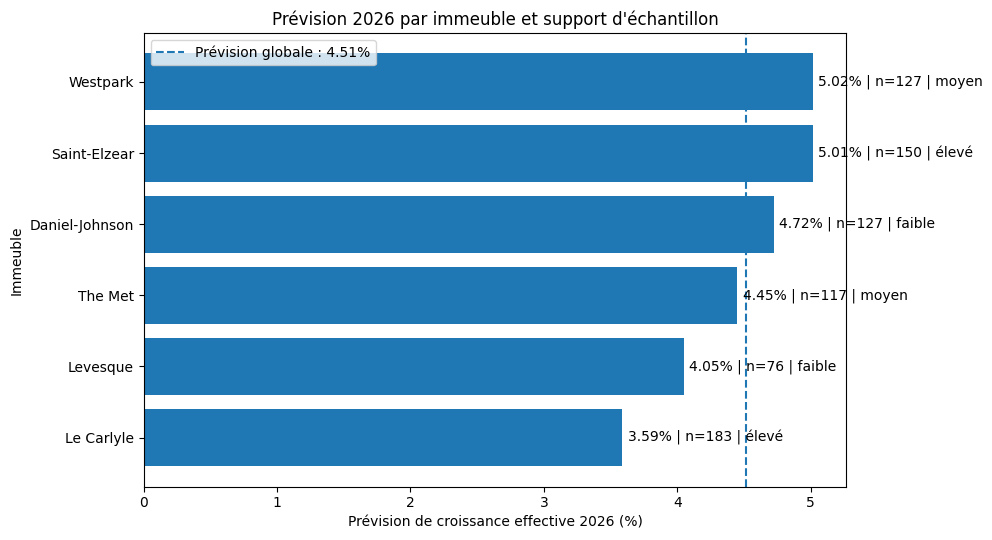

In [84]:
fig, ax = plt.subplots(
    figsize=(10, 5.5)
)

plot_data = (
    building_dashboard
    .sort_values(
        "forecast_2026_pct"
    )
)

bars = ax.barh(
    plot_data["sBuilding"],
    plot_data["forecast_2026_pct"]
)

ax.axvline(
    final_estimate_2026,
    linestyle="--",
    label=(
        "Prévision globale : "
        f"{final_estimate_2026:.2f}%"
    )
)

for bar, (_, row) in zip(
    bars,
    plot_data.iterrows()
):
    ax.text(
        bar.get_width() + 0.04,
        bar.get_y()
        + bar.get_height() / 2,
        (
            f"{row['forecast_2026_pct']:.2f}% | "
            f"n={int(row['n_pairs'])} | "
            f"{row['sample_support']}"
        ),
        va="center"
    )

ax.set_xlabel(
    "Prévision de croissance effective 2026 (%)"
)

ax.set_ylabel("Immeuble")

ax.set_title(
    "Prévision 2026 par immeuble et support d'échantillon"
)

ax.legend()

plt.tight_layout()
plt.show()

### Lecture du tableau de bord

Le trait vertical représente la prévision centrale du portefeuille, soit
4,51 %. Les prévisions par immeuble restent dans une plage relativement
resserrée autour de cette valeur.

Le dashboard présente conjointement le niveau de prévision et le volume
d'observations disponible, afin d'éviter qu'une estimation issue d'un petit
segment soit interprétée avec la même certitude qu'une estimation beaucoup
mieux documentée.

L'indicateur de support d'échantillon est descriptif : il ne constitue pas
un intervalle de confiance.

## 20. Conclusion générale

Nous estimons la hausse de loyer 2026 de Collection Équinoxe à **4,51 %**.

Cette valeur désigne précisément la **croissance médiane annualisée du loyer effectif à unité constante**. Elle ne représente ni la variation de la médiane brute du portefeuille, ni une hausse contractuelle moyenne.

Notre analyse montre que la variation brute des loyers est fortement exposée aux effets de composition. En 2023, par exemple, la médiane globale augmente de 10,85 %, alors que la croissance contractuelle à unité constante n'est que de 2,29 %. L'arrivée de nouveaux immeubles et l'évolution du mix de logements expliquent une part importante de cette divergence.

La comparaison entre `sRent` et `sRentEffective` montre également que les concessions absorbent une part croissante des hausses contractuelles. En 2025, la croissance contractuelle médiane atteint 7,05 %, contre seulement 3,58 % en effectif.

Notre prévision repose donc sur un mécanisme simple :

\[
Forecast_t =
AskingGrowth_{t-1}
-
ConcessionDrag_{t-1}
\]

La méthode obtient une MAE de **1,48 point de pourcentage** sur les backtests 2023, 2024 et 2025, légèrement meilleure que la baseline de persistance à 1,54 point.

Compte tenu du faible nombre d'années de backtest, nous accompagnons l'estimation centrale d'une plage de sensibilité empirique d'environ **3,04 % à 5,99 %**. Cette plage ne constitue pas un intervalle de confiance probabiliste.

Les données de la SCHL et de Statistique Canada ainsi que les cadres réglementaires du Québec et de l'Ontario sont utilisés pour vérifier la cohérence économique de la prévision. Ils ne sont pas combinés au moyen de pondérations arbitraires.

Les tests de robustesse supplémentaires confortent cet ordre de grandeur.
Une définition alternative du `concession_drag` produit une prévision de
4,63 %, soit seulement 0,12 point de différence avec le modèle principal.

En complément des trois backtests exigés, l'application inchangée de la
méthode sur 2019-2025 obtient une MAE d'environ 1,19 point de pourcentage.
Le modèle présente également un biais signé moyen de +0,85 point sur les
trois backtests officiels ; ce biais est documenté mais n'est pas utilisé
pour corriger la prévision, afin d'éviter un ajustement sur seulement trois
observations.

**Estimation centrale 2026 : 4,51 %.**

## 21. Reproductibilité

### Exécution

Le notebook doit être exécuté de haut en bas dans le même dossier que les quatre fichiers fournis :

- `equinoxe_listings.csv`
- `equinoxe_lease_history.csv`
- `equinoxe_concessions.csv`
- `equinoxe_asking_history.csv`

Aucun modèle entraîné n'est sérialisé : la méthode retenue est déterministe et recalculée directement à partir des données.

In [85]:
import sys
import matplotlib

versions = pd.DataFrame([
    {"package": "Python", "version": sys.version.split()[0]},
    {"package": "pandas", "version": pd.__version__},
    {"package": "numpy", "version": np.__version__},
    {"package": "matplotlib", "version": matplotlib.__version__},
])

versions

,package,version
0,Python,3.11.9
1,pandas,2.2.3
2,numpy,2.2.4
3,matplotlib,3.10.1


## 22. Références et documentation

### Données internes

Les quatre fichiers CSV Yardi fournis dans le cadre du défi JADCO ont été
utilisés uniquement dans l'environnement du challenge et ne sont pas
redistribués avec le livrable :

- `equinoxe_listings.csv`
- `equinoxe_lease_history.csv`
- `equinoxe_concessions.csv`
- `equinoxe_asking_history.csv`

### Société canadienne d'hypothèques et de logement — SCHL

**Rental Market Report / Enquête sur les logements locatifs**, éditions
2022 à 2025.

Utilisation dans le notebook :

- loyers et taux d'inoccupation pour Montréal et Ottawa ;
- évolution des loyers de deux chambres ;
- distinction logements avec / sans changement de locataire ;
- contexte du marché locatif d'Ottawa.

Publication du rapport 2025 : **11 décembre 2025**.

URL : https://www.cmhc-schl.gc.ca/professionals/housing-markets-data-and-research/market-reports/rental-market-reports-major-centres

Date de consultation : 3 octobre 2026.

### Statistique Canada

**Tableau 18-10-0004-01 — Indice des prix à la consommation, mensuel,
non désaisonnalisé**, composante loyers.

Utilisation :

- Québec : +9,6 % sur 12 mois en septembre 2025 ;
- Ontario : +3,5 % sur 12 mois en septembre 2025.

Diffusion utilisée : **21 octobre 2025**.

URL : https://www150.statcan.gc.ca/n1/daily-quotidien/251021/cg-a005-fra.htm

Date de consultation : 3 octobre 2026.

### Gouvernement de l'Ontario

**2026 Rent Increase Guideline : 2,1 %.**

Documentation utilisée pour distinguer :

- les logements assujettis ;
- l'exemption liée à la première occupation résidentielle après
  le 15 novembre 2018 ;
- les relocations, auxquelles le guideline ne s'applique pas.

URL : https://www.ontario.ca/page/residential-rent-increases

Date de consultation : 3 octobre 2026.

### Tribunal administratif du logement — Québec

**Le calcul de l'ajustement des loyers en 2026.**

Le pourcentage de base de 3,1 % a été publié le **19 janvier 2026**.
Il est documenté comme contexte postérieur au cutoff et n'entre pas dans
la prévision principale.

URL : https://www.tal.gouv.qc.ca/fr/actualites/detail?code=le-calcul-de-l-ajustement-des-loyers-en-2026

Date de consultation : 3 octobre 2026.

### Bibliothèques

Les versions exactes de Python, pandas, NumPy et Matplotlib utilisées sont
affichées dans la section Reproductibilité.

### Utilisation de l'IA

Un assistant d'IA a été utilisé pour soutenir :

- l'explication de concepts immobiliers et statistiques ;
- la structuration de l'analyse ;
- la proposition et la révision de code ;
- la recherche et la vérification documentaire ;
- la présentation du raisonnement.

Les calculs, sorties, hypothèses, choix méthodologiques et références ont
été exécutés, inspectés et validés dans le notebook par l'équipe.